# Compare Simulation Excel Results

This notebook compares time-series columns from Excel/CSV result files. Use `COMPARE_INPUT_MODE` to choose one of three workflows:

- `case_definitions`: existing D-case metadata list under `RESULTS_ROOT`.
- `scan_folder`: find files automatically under a folder using a glob pattern.
- `explicit_files`: compare only the file paths and columns you list manually.

All package imports are kept in the first code cell. User-editable comparison settings are in the second code cell.


In [1]:
# ===== Imports and plotting defaults =====
import math
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from CoolProp.CoolProp import PhaseSI, PropsSI
except ImportError:
    PhaseSI = None
    PropsSI = None

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
# ===== User configuration =====
# Choose how result files are collected: "case_definitions", "scan_folder", or "explicit_files".
COMPARE_INPUT_MODE = "explicit_files"

# Common reader options.
TIME_COLUMN = None  # Set to None to auto-detect common names such as time/Time/day/year.
DEFAULT_SHEET_NAME = 0
SKIP_INITIAL_TIME_STEPS = 0  # Integer or dict keyed by case label.
MAX_COMPARE_TIME_DAYS = None  # Set to None to use the full available time range.

# Derived aquifer diagnostic: producer CO2/H2O mass-rate ratio at wellhead.
CO2_H2O_RATIO_COLUMN = "producer_CO2_H2O_mass_rate_ratio_at_wh"

# Variables with the same column name in every file.
# Run the Inspect columns cell first if you need to see available names.
VARIABLES = [
    "well_I1_BHP",
    "well_P1_BHP",
    "well_I1_BHT",
    "well_P1_BHT",
    "well_P1_mass_rate_CO2_rich_at_wh",
    "well_I1_mass_rate_CO2_rich_at_wh",
    CO2_H2O_RATIO_COLUMN,
    "heat_extraction_rate_MW",
]

# Optional: use this when different files use different column names for the same comparison.
# Leave empty to compare each name in VARIABLES directly.
# Example:
# COMPARISON_SETS = [
#     {
#         "name": "producer BHP",
#         "base_label": "baseline",
#         "columns": {
#             "baseline": "well_P1_BHP",
#             "case A": "well_PROD_BHP",
#         },
#     },
# ]
COMPARISON_SETS = []

# Baseline case label for differences and error statistics.
BASE_LABEL = "Fine"

# Time unit conversion. DARTS time is usually days; use 365 or 365.25 for years.
TIME_SCALE = 365
TIME_LABEL = "time, years"

# Figure output directory. Set to None to avoid saving figures.
OUTPUT_DIR = None

# Plot appearance and rate handling.
SMOOTH_PLOT_POINTS = 600
ABS_RATE_VARIABLES = True
RATE_KEYWORDS = ("rate", "_q")

# ----- Mode 1: case_definitions -----
# One well_time_data.xlsx file per case under RESULTS_ROOT / case / EXCEL_NAME.
RESULTS_ROOT = Path(r"E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C")
EXCEL_NAME = "well_time_data.xlsx"

CASE_DEFINITIONS = [
    # {"case": "D-01", "label": "D-01 Baseline", "depth_m": 2000, "scenario": "Baseline", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "D-02", "label": "D-02 Heterogeneity R78", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 60"},
    # {"case": "D-03", "label": "D-03 Heterogeneity R85", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 43"},
    # {"case": "D-04", "label": "D-04 Heterogeneity R66", "depth_m": 2000, "scenario": "Heterogeneity", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 8"},
    # {"case": "D-05", "label": "D-05 Injection low", "depth_m": 2000, "scenario": "Injection rate: low", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 25, "medium": "Homogeneous"},
    # {"case": "D-06", "label": "D-06 Injection high", "depth_m": 2000, "scenario": "Injection rate: high", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 100, "medium": "Homogeneous"},
    # {"case": "D-07", "label": "D-07 Kh low", "depth_m": 2000, "scenario": "Horizontal permeability: low", "horizontal_permeability_md": 200, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "D-08", "label": "D-08 Kh medium-low", "depth_m": 2000, "scenario": "Horizontal permeability: medium-low", "horizontal_permeability_md": 400, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "D-09", "label": "D-09 Kh high", "depth_m": 2000, "scenario": "Horizontal permeability: high", "horizontal_permeability_md": 1600, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "D-10", "label": "D-10 Strong anisotropy", "depth_m": 2000, "scenario": "Strong vertical anisotropy", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.01, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "D-11", "label": "D-11 Isotropic permeability", "depth_m": 2000, "scenario": "Isotropic permeability", "horizontal_permeability_md": 800, "vertical_anisotropy": 1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "M-01-single_phase", "label": "M-01 Baseline", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    # {"case": "M-02_single_phase", "label": "M-02 Heterogeneity R78", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 78"},
    # {"case": "M-03_single_phase", "label": "M-03 Heterogeneity R85", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 85"},
    # {"case": "M-04_single_phase", "label": "M-04 Heterogeneity R66", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 66"},
    # {"case": "M-05-single_phase", "label": "M-05 Injection low", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 25, "medium": "Homogeneous"},
    # {"case": "M-06-single_phase", "label": "M-06 Injection high", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 100, "medium": "Homogeneous"},
    # {"case": "M-07-single_phase", "label": "M-07 Isotropic permeability", "depth_m": 1000, "scenario": "Middle reservoir", "horizontal_permeability_md": 800, "vertical_anisotropy": 1, "injection_rate": 50, "medium": "Homogeneous"}
    {"case":"S-01_single_phase_17C", "label":"S-01 Baseline", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Homogeneous"},
    {"case":"S-02_single_phase_17C", "label":"S-02 Heterogeneity R78", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 78"},
    {"case":"S-03_single_phase_17C", "label":"S-03 Heterogeneity R85", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 85"},
    {"case":"S-04_single_phase_17C", "label":"S-04 Heterogeneity R66", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": "realization-specific", "vertical_anisotropy": 0.1, "injection_rate": 50, "medium": "Realization 66"},
    # {"case":"S-05_single_phase_17C", "label":"S-05 Injection low", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 25, "medium": "Homogeneous"},
    # {"case":"S-06_single_phase_17C", "label":"S-06 Injection high", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 0.1, "injection_rate": 100, "medium": "Homogeneous"},
    # {"case":"S-07_single_phase_17C", "label":"S-07 Isotropic permeability", "depth_m": 500, "scenario": "Shallow reservoir, 17C", "horizontal_permeability_md": 800, "vertical_anisotropy": 1, "injection_rate": 50, "medium": "Homogeneous"}
]

# ----- Mode 2: scan_folder -----
# Scans the whole folder tree when FOLDER_SCAN_GLOB starts with **/.
FOLDER_SCAN_ROOT = RESULTS_ROOT
FOLDER_SCAN_GLOB = f"**/{EXCEL_NAME}"
FOLDER_LABEL_MODE = "parent"  # "parent", "stem", or "relative"

# ----- Mode 3: explicit_files -----
# Add only the files you want to compare. Optional "columns" documents the intended columns.
EXPLICIT_FILES = [
    # To stitch aquifer stage outputs into one curve, replace one entry with:
    # {
    #     "label": "Coarse",
    #     "paths": [
    #         {"path": Path(r"E:\Repo_darts\open-darts\output_coarse_open_aquifer_new_stage1_inj_only\well_time_data.xlsx"), "stage": "stage1"},
    #         {"path": Path(r"E:\Repo_darts\open-darts\output_coarse_open_aquifer_new\well_time_data.xlsx"), "stage": "stage2", "time_offset": "continue"},
    #     ],
    #     "sheet_name": 0,
    # },
    # {
    #     "label": "Fine",
    #     "paths": [
    #         {"path": Path(r"E:\Thesis results\aquifer_system\output_fine_open_aquifer_new_stage1_inj_only\well_time_data.xlsx"), "stage": "stage1"},
    #         {"path": Path(r"E:\Thesis results\aquifer_system\output_fine_open_aquifer_new\well_time_data.xlsx"), "stage": "stage2", "time_offset": "continue"},
    #     ],
    #     "sheet_name": 0,
    # },
    {
        "label":"pure_CO2_high_rcond",
        "paths":[
            {"path": Path(r"E:\Thesis results\Pure_CO2_S\bhp control, 83c, 690well_dis\D-01\well_time_data.xlsx")},
        ],
        "sheet_name": 0,
    },
    {
        "label":"pure_CO2_low_rcond",
        "paths":[
            {"path": Path(r"E:\Repo_darts\open-darts\LGR_kairan\Egg model\output_lgr_pure_co2\well_time_data.xlsx")},
        ],
        "sheet_name": 0,
    },
    
]

# ----- Optional derived heat extraction rate -----
ADD_HEAT_EXTRACTION_RATE = True

HEAT_EXTRACTION_COLUMN = "heat_extraction_rate_MW"
HEAT_EXTRACTION_FLUID = "CO2"
PRODUCER_MASS_RATE_COLUMN = "well_P1_mass_rate_CO2_rich_at_wh"
PRODUCER_PRESSURE_COLUMN = "well_P1_BHP"
PRODUCER_TEMPERATURE_COLUMN = "well_P1_BHT"
INJECTOR_PRESSURE_COLUMN = "well_I1_BHP"
INJECTOR_TEMPERATURE_COLUMN = "well_I1_BHT"


In [3]:
# ===== Common loading and comparison helpers =====
def natural_sort_key(value):
    return [int(part) if part.isdigit() else part.lower() for part in re.split(r"(\d+)", str(value))]


def safe_filename(text):
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(text)).strip("_")


def read_table(path, sheet_name=0):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path, sheet_name=sheet_name)
    raise ValueError(f"Unsupported file type: {path.suffix}")


def clean_columns(df):
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]
    return df


def find_time_column(df, preferred=None):
    if preferred is not None:
        if preferred not in df.columns:
            raise KeyError(f"TIME_COLUMN={preferred!r} not found. Available columns: {list(df.columns)}")
        return preferred
    for col in ["time", "Time", "TIME", "t", "T", "day", "days", "year", "years"]:
        if col in df.columns:
            return col
    raise KeyError(f"Could not infer time column. Available columns: {list(df.columns)}")


def steps_to_skip(skip_initial_steps, label):
    value = skip_initial_steps.get(label, 0) if isinstance(skip_initial_steps, dict) else skip_initial_steps
    value = int(value)
    if value < 0:
        raise ValueError("skip_initial_steps must be non-negative")
    return value


def path_display(path):
    if isinstance(path, (list, tuple)):
        return " + ".join(str(Path(item.get("path", item) if isinstance(item, dict) else item)) for item in path)
    return str(Path(path))


def path_name(path):
    if isinstance(path, (list, tuple)):
        return " + ".join(Path(item.get("path", item) if isinstance(item, dict) else item).name for item in path)
    return Path(path).name


def require_columns(df, columns, path):
    missing = [col for col in columns if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in {path_name(path)}: {missing}. Available columns: {list(df.columns)}")


def specs_from_case_definitions(results_root=RESULTS_ROOT, case_definitions=CASE_DEFINITIONS, excel_name=EXCEL_NAME):
    return [
        {"label": case["label"], "path": Path(results_root) / case["case"] / excel_name, "sheet_name": DEFAULT_SHEET_NAME, **case}
        for case in case_definitions
    ]


def specs_from_folder(root=FOLDER_SCAN_ROOT, glob_pattern=FOLDER_SCAN_GLOB, label_mode=FOLDER_LABEL_MODE):
    root = Path(root)
    specs = []
    for path in sorted(root.glob(glob_pattern), key=natural_sort_key):
        if not path.is_file():
            continue
        if label_mode == "stem":
            label = path.stem
        elif label_mode == "relative":
            label = str(path.relative_to(root).with_suffix(""))
        else:
            label = path.parent.name
        specs.append({"label": label, "path": path, "sheet_name": DEFAULT_SHEET_NAME})
    if not specs:
        raise FileNotFoundError(f"No files matched {glob_pattern!r} under {root}")
    return specs


def specs_from_explicit_files(files=EXPLICIT_FILES):
    specs = []
    for index, item in enumerate(files, start=1):
        first_path = item.get("path")
        if first_path is None and item.get("paths"):
            first_item = item["paths"][0]
            first_path = first_item.get("path", first_item) if isinstance(first_item, dict) else first_item
        first_path = Path(first_path)
        label = item.get("label") or first_path.parent.name or f"case {index}"
        specs.append({"label": label, "sheet_name": item.get("sheet_name", DEFAULT_SHEET_NAME), **item})
    if not specs:
        raise ValueError("EXPLICIT_FILES is empty. Add at least two file specs or change COMPARE_INPUT_MODE.")
    return specs


def build_excel_specs(mode=COMPARE_INPUT_MODE):
    if mode == "case_definitions":
        return specs_from_case_definitions()
    if mode == "scan_folder":
        return specs_from_folder()
    if mode == "explicit_files":
        return specs_from_explicit_files()
    raise ValueError(f"Unknown COMPARE_INPUT_MODE: {mode!r}")


def co2_enthalpy_kj_per_kg(pressure_bar, temperature_k):
    if PropsSI is None:
        raise ImportError("CoolProp is required to compute CO2 enthalpy. Install it with: pip install CoolProp")
    pressure_pa = np.asarray(pressure_bar, dtype=float) * 1e5
    temperature_k = np.asarray(temperature_k, dtype=float)
    enthalpy_j_per_kg = PropsSI("H", "P", pressure_pa, "T", temperature_k, HEAT_EXTRACTION_FLUID)
    return enthalpy_j_per_kg / 1000.0


def first_existing_column(df, candidates):
    for column in candidates:
        if column in df.columns:
            return column
    return None


def add_co2_h2o_mass_rate_ratio(df, path=None, out_col=CO2_H2O_RATIO_COLUMN):
    df = df.copy()
    co2_col = first_existing_column(df, [
        "well_P1_mass_rate_CO2_at_wh",
        "well_P1_mass_rate_CO2_rich_at_wh",
        "well_P1_mass_rate_LCO2_at_wh",
    ])
    h2o_col = first_existing_column(df, [
        "well_P1_mass_rate_H2O_at_wh",
        "well_P1_mass_rate_aqueous_at_wh",
    ])
    df[out_col] = np.nan
    df[f"{out_col}_co2_column"] = co2_col
    df[f"{out_col}_h2o_column"] = h2o_col
    if co2_col is None or h2o_col is None:
        return df
    co2_rate = np.abs(pd.to_numeric(df[co2_col], errors="coerce"))
    h2o_rate = np.abs(pd.to_numeric(df[h2o_col], errors="coerce"))
    valid = np.isfinite(co2_rate) & np.isfinite(h2o_rate) & (h2o_rate > 0.0)
    df.loc[valid, out_col] = co2_rate[valid] / h2o_rate[valid]
    return df


def add_heat_extraction_rate(df, path):
    required = [
        PRODUCER_MASS_RATE_COLUMN,
        PRODUCER_PRESSURE_COLUMN,
        PRODUCER_TEMPERATURE_COLUMN,
        INJECTOR_PRESSURE_COLUMN,
        INJECTOR_TEMPERATURE_COLUMN,
    ]
    require_columns(df, required, path)
    valid = df[required].apply(pd.to_numeric, errors="coerce").notna().all(axis=1)
    if not valid.all():
        df = df.copy()
        df[HEAT_EXTRACTION_COLUMN] = np.nan
        df[f"{HEAT_EXTRACTION_COLUMN}_h_produced_kJ_per_kg"] = np.nan
        df[f"{HEAT_EXTRACTION_COLUMN}_h_injected_kJ_per_kg"] = np.nan
    if not valid.any():
        return df
    producer_mass_rate_kg_per_day = np.abs(pd.to_numeric(df.loc[valid, PRODUCER_MASS_RATE_COLUMN], errors="coerce"))
    h_produced = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df.loc[valid, PRODUCER_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df.loc[valid, PRODUCER_TEMPERATURE_COLUMN], errors="coerce"),
    )
    h_injected = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df.loc[valid, INJECTOR_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df.loc[valid, INJECTOR_TEMPERATURE_COLUMN], errors="coerce"),
    )
    df.loc[valid, HEAT_EXTRACTION_COLUMN] = producer_mass_rate_kg_per_day * (h_produced - h_injected) / 86400.0 / 1000.0
    df.loc[valid, f"{HEAT_EXTRACTION_COLUMN}_h_produced_kJ_per_kg"] = h_produced
    df.loc[valid, f"{HEAT_EXTRACTION_COLUMN}_h_injected_kJ_per_kg"] = h_injected
    return df


def table_items_from_spec(spec):
    raw_items = spec.get("paths", spec.get("path"))
    if not isinstance(raw_items, (list, tuple)):
        raw_items = [raw_items]
    items = []
    for index, raw_item in enumerate(raw_items, start=1):
        item = dict(raw_item) if isinstance(raw_item, dict) else {"path": raw_item}
        item.setdefault("sheet_name", spec.get("sheet_name", DEFAULT_SHEET_NAME))
        item.setdefault("stage", f"stage{index}")
        if index > 1:
            item.setdefault("time_offset", "continue")
        items.append(item)
    return items


def load_staged_table(spec, time_column=None):
    items = table_items_from_spec(spec)
    frames = []
    common_time_col = None
    current_end = None
    for index, item in enumerate(items):
        path = Path(item["path"])
        df = clean_columns(read_table(path, item.get("sheet_name", DEFAULT_SHEET_NAME)))
        tcol = find_time_column(df, time_column)
        common_time_col = common_time_col or tcol
        df[tcol] = pd.to_numeric(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol]).sort_values(tcol).drop_duplicates(subset=[tcol], keep="last")
        if df.empty:
            continue
        time_offset = item.get("time_offset")
        if index > 0 and (time_offset is None or time_offset == "continue"):
            start_time = df[tcol].iloc[0]
            df[tcol] = df[tcol] - start_time + current_end
        elif time_offset not in (None, "continue"):
            df[tcol] = df[tcol] + float(time_offset)
        if tcol != common_time_col:
            df = df.rename(columns={tcol: common_time_col})
        df["source_stage"] = item.get("stage", f"stage{index + 1}")
        df["source_path"] = str(path)
        current_end = df[common_time_col].max() if current_end is None else max(current_end, df[common_time_col].max())
        frames.append(df)
    if not frames:
        raise ValueError(f"No rows found in staged input for {spec['label']!r}")
    df = pd.concat(frames, ignore_index=True, sort=False)
    df = df.sort_values(common_time_col).drop_duplicates(subset=[common_time_col], keep="last")
    return df, common_time_col


def load_cases(excel_specs, time_column=None, skip_initial_steps=0, add_heat_extraction=ADD_HEAT_EXTRACTION_RATE):
    cases = {}
    for spec in excel_specs:
        label = spec["label"]
        path = spec.get("paths", spec.get("path"))
        df, tcol = load_staged_table(spec, time_column)
        if MAX_COMPARE_TIME_DAYS is not None:
            df = df[df[tcol] <= MAX_COMPARE_TIME_DAYS]
        skip_count = steps_to_skip(skip_initial_steps, label)
        if skip_count:
            df = df.iloc[skip_count:]
        if df.empty:
            raise ValueError(f"No rows left for {label!r} after skipping {skip_count} initial time steps")
        if add_heat_extraction:
            df = add_heat_extraction_rate(df, path)
        df = add_co2_h2o_mass_rate_ratio(df, path)
        cases[label] = {"df": df, "time_col": tcol, "path": path, "metadata": spec}
    return cases


def available_columns(cases):
    for label, case in cases.items():
        requested = case.get("metadata", {}).get("columns")
        print(f"[{label}] {path_display(case['path'])}")
        print("time column:", case["time_col"])
        if requested:
            print("requested columns:", requested)
        for col in case["df"].columns:
            print("  ", col)


def is_rate_variable(variable):
    name = str(variable).lower()
    if "ratio" in name:
        return False
    return ABS_RATE_VARIABLES and any(key in name for key in RATE_KEYWORDS)


def display_variable_name(variable):
    return f"abs({variable})" if is_rate_variable(variable) else str(variable)


def smooth_xy(x, y, n_points=None):
    n_points = SMOOTH_PLOT_POINTS if n_points is None else n_points
    if len(x) < 3:
        return x, y
    order = np.argsort(x)
    x = np.asarray(x, dtype=float)[order]
    y = np.asarray(y, dtype=float)[order]
    unique_x, unique_idx = np.unique(x, return_index=True)
    unique_y = y[unique_idx]
    if len(unique_x) < 3:
        return unique_x, unique_y
    dense_x = np.linspace(unique_x[0], unique_x[-1], max(n_points, len(unique_x)))
    dense_y = np.interp(dense_x, unique_x, unique_y)
    return dense_x, dense_y


def comparison_column(comparison, label):
    if isinstance(comparison, str):
        return comparison
    return comparison.get("columns", {}).get(label, comparison["name"])


def comparison_name(comparison):
    return comparison if isinstance(comparison, str) else comparison["name"]


def comparison_base_label(comparison, default_base_label=BASE_LABEL):
    return default_base_label if isinstance(comparison, str) else comparison.get("base_label", default_base_label)


def resolve_comparisons(cases, variables=VARIABLES, comparison_sets=COMPARISON_SETS):
    if comparison_sets:
        return comparison_sets
    return list(variables)


def get_series(case, variable):
    df = case["df"]
    tcol = case["time_col"]
    if variable not in df.columns:
        raise KeyError(f"Variable {variable!r} not found in {path_name(case['path'])}")
    x = pd.to_numeric(df[tcol], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[variable], errors="coerce").to_numpy(dtype=float)
    if is_rate_variable(variable):
        y = np.abs(y)
    mask = np.isfinite(x) & np.isfinite(y)
    return x[mask], y[mask]


def get_comparison_series(case, comparison, label):
    return get_series(case, comparison_column(comparison, label))


def common_time_grid(cases, comparison, base_label):
    base_x, _ = get_comparison_series(cases[base_label], comparison, base_label)
    xmin = max(np.min(get_comparison_series(case, comparison, label)[0]) for label, case in cases.items())
    xmax = min(np.max(get_comparison_series(case, comparison, label)[0]) for label, case in cases.items())
    grid = base_x[(base_x >= xmin) & (base_x <= xmax)]
    if grid.size == 0:
        raise ValueError(f"No overlapping time range for {comparison_name(comparison)!r}")
    return grid


def interpolate_to_grid(x, y, grid):
    order = np.argsort(x)
    return np.interp(grid, x[order], y[order])


def compare_variable(cases, comparison, base_label=BASE_LABEL):
    base_label = comparison_base_label(comparison, base_label)
    grid = common_time_grid(cases, comparison, base_label)
    aligned = {}
    for label, case in cases.items():
        x, y = get_comparison_series(case, comparison, label)
        aligned[label] = interpolate_to_grid(x, y, grid)
    base = aligned[base_label]
    rows = []
    for label, y in aligned.items():
        diff = y - base
        denom = np.maximum(np.abs(base), 1e-12)
        rel = diff / denom
        rows.append({
            "comparison": comparison_name(comparison),
            "case": label,
            "column": comparison_column(comparison, label),
            "base": base_label,
            "max_abs_diff": np.nanmax(np.abs(diff)),
            "mean_abs_diff": np.nanmean(np.abs(diff)),
            "rmse": math.sqrt(np.nanmean(diff ** 2)),
            "max_abs_rel_diff": np.nanmax(np.abs(rel)),
            "mean_abs_rel_diff": np.nanmean(np.abs(rel)),
        })
    return grid, aligned, pd.DataFrame(rows)


## Load And Inspect Columns

Run this cell after editing the configuration. It builds `EXCEL_SPECS` from the selected mode, loads all cases, and prints available columns.


In [4]:
EXCEL_SPECS = build_excel_specs(COMPARE_INPUT_MODE)
cases = load_cases(EXCEL_SPECS, TIME_COLUMN, SKIP_INITIAL_TIME_STEPS,add_heat_extraction=None)
comparisons = resolve_comparisons(cases, VARIABLES, COMPARISON_SETS)

print(f"input mode: {COMPARE_INPUT_MODE}")
print(f"loaded cases: {len(cases)}")
print(f"comparisons: {[comparison_name(item) for item in comparisons]}")
available_columns(cases)


input mode: explicit_files
loaded cases: 2
comparisons: ['well_I1_BHP', 'well_P1_BHP', 'well_I1_BHT', 'well_P1_BHT', 'well_P1_mass_rate_CO2_rich_at_wh', 'well_I1_mass_rate_CO2_rich_at_wh', 'heat_extraction_rate_MW']
[pure_CO2_high_rcond] E:\Thesis results\Pure_CO2_S\bhp control, 83c, 690well_dis\D-01\well_time_data.xlsx
time column: time
   time
   well_I1_BHP
   well_I1_BHT
   well_P1_BHP
   well_P1_BHT
   well_I1_perf_0_molar_rate_V
   well_I1_perf_0_molar_rate_LCO2
   well_I1_perf_1_molar_rate_V
   well_I1_perf_1_molar_rate_LCO2
   well_I1_perf_2_molar_rate_V
   well_I1_perf_2_molar_rate_LCO2
   well_I1_perf_3_molar_rate_V
   well_I1_perf_3_molar_rate_LCO2
   well_I1_perf_4_molar_rate_V
   well_I1_perf_4_molar_rate_LCO2
   well_I1_perf_5_molar_rate_V
   well_I1_perf_5_molar_rate_LCO2
   well_I1_perf_6_molar_rate_V
   well_I1_perf_6_molar_rate_LCO2
   well_P1_perf_0_molar_rate_V
   well_P1_perf_0_molar_rate_LCO2
   well_P1_perf_1_molar_rate_V
   well_P1_perf_1_molar_rate_LCO2
   well

## Plot Variables

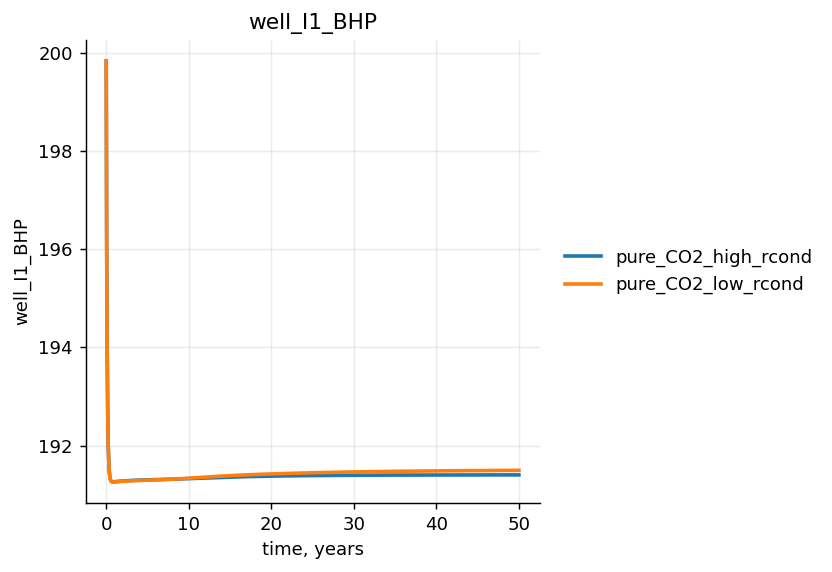

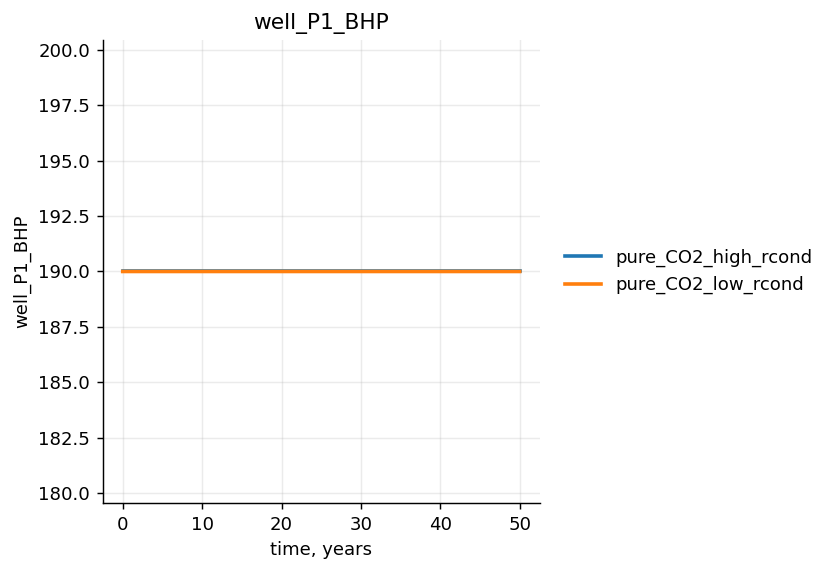

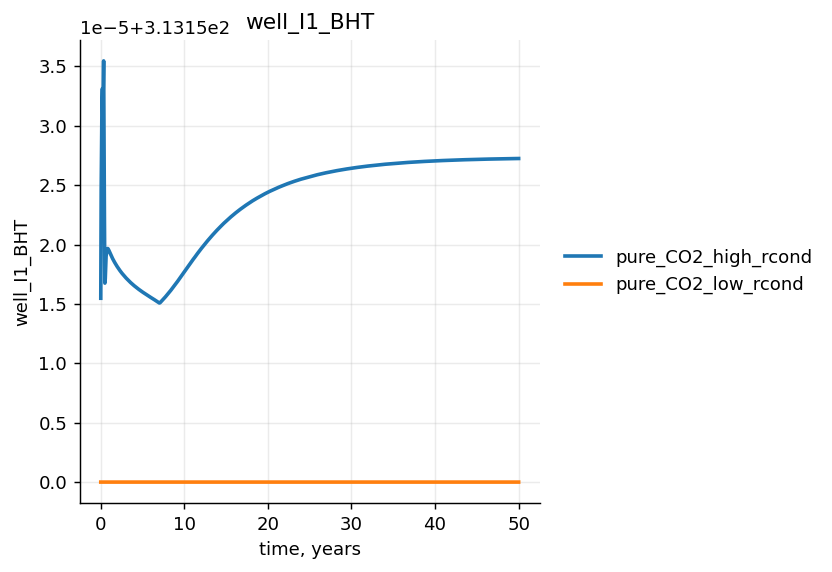

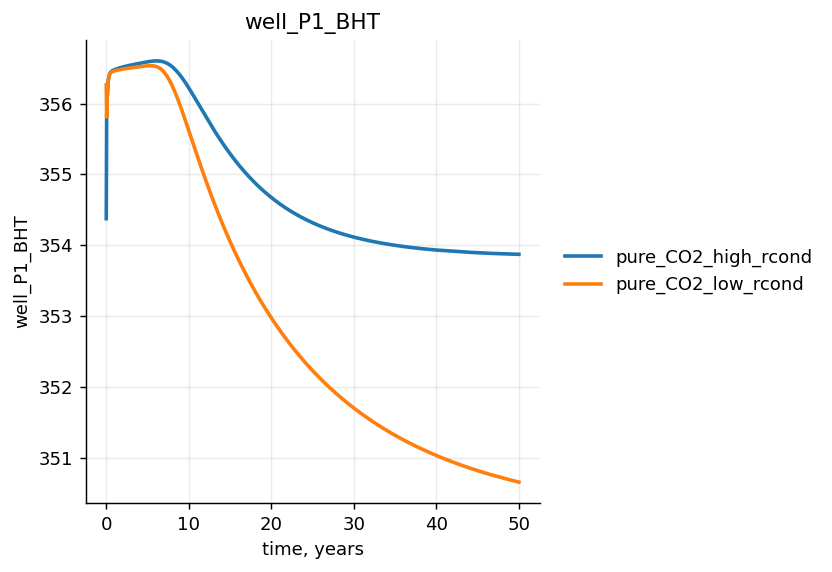

KeyError: "Variable 'well_P1_mass_rate_CO2_rich_at_wh' not found in well_time_data.xlsx"

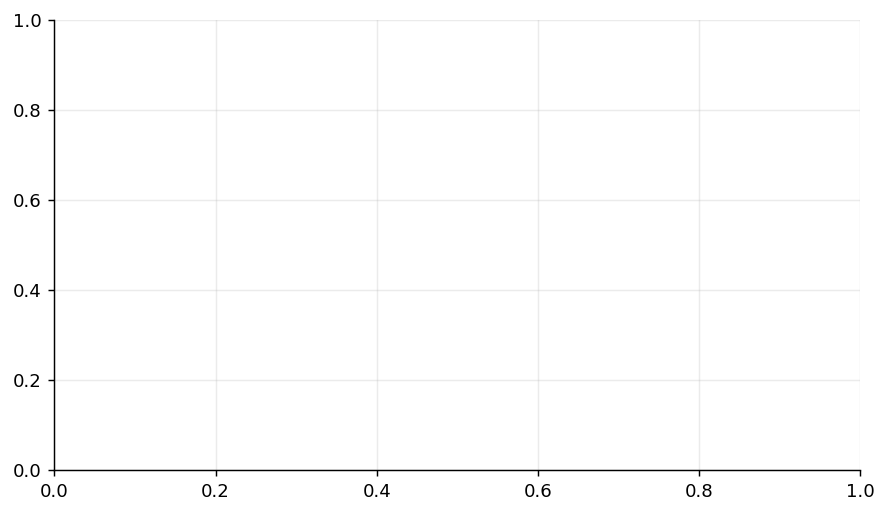

In [5]:
def plot_case_curve(cases, comparison, time_scale=1.0, time_label="time"):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, case in cases.items():
        column = comparison_column(comparison, label)
        x, y = get_series(case, column)
        xs, ys = smooth_xy(x / time_scale, y)
        ax.plot(xs, ys, linewidth=2.0, label=label)
    ax.set_title(comparison_name(comparison))
    ax.set_xlabel(time_label)
    ax.set_ylabel(display_variable_name(comparison_name(comparison)))
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig


def plot_case_curves(cases, comparisons, time_scale=1.0, time_label="time"):
    figures = {}
    for comparison in comparisons:
        name = comparison_name(comparison)
        figures[name] = plot_case_curve(cases, comparison, time_scale, time_label)
        plt.show()
    return figures


case_curve_figures = plot_case_curves(cases, comparisons, TIME_SCALE, TIME_LABEL)


## Difference Against Base Case

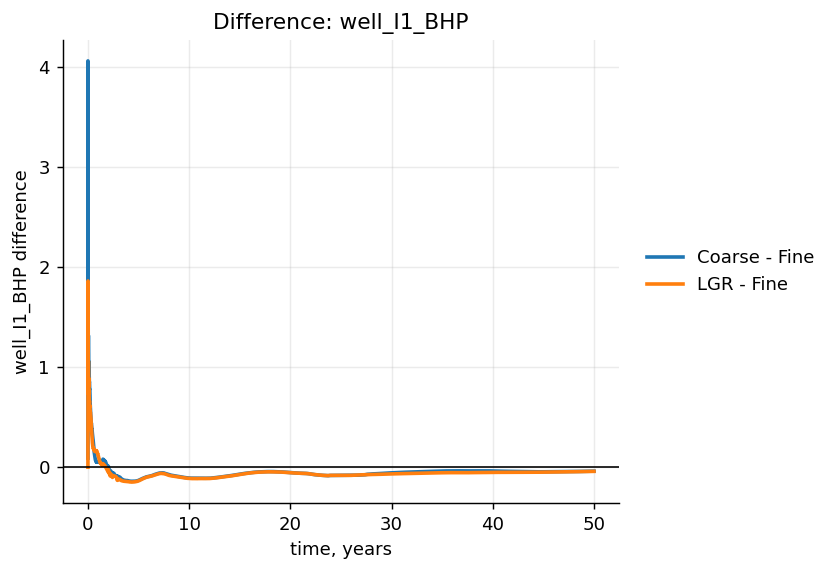

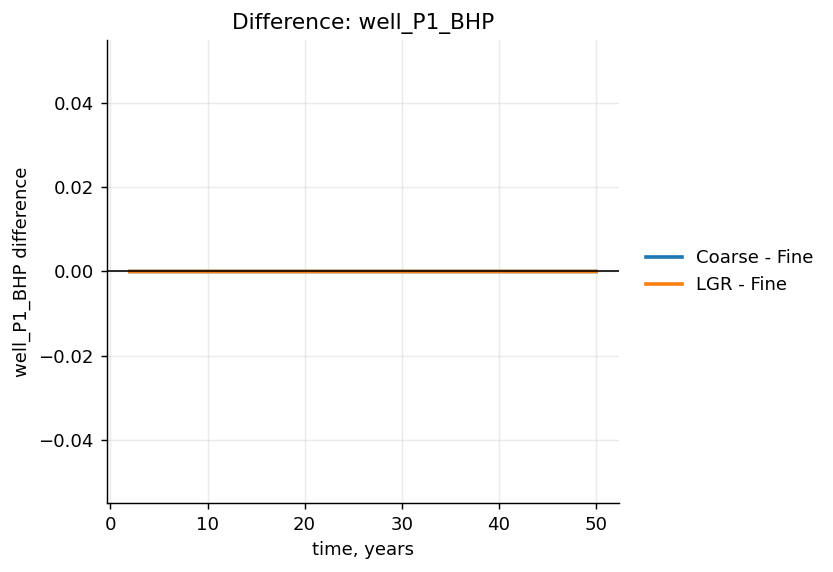

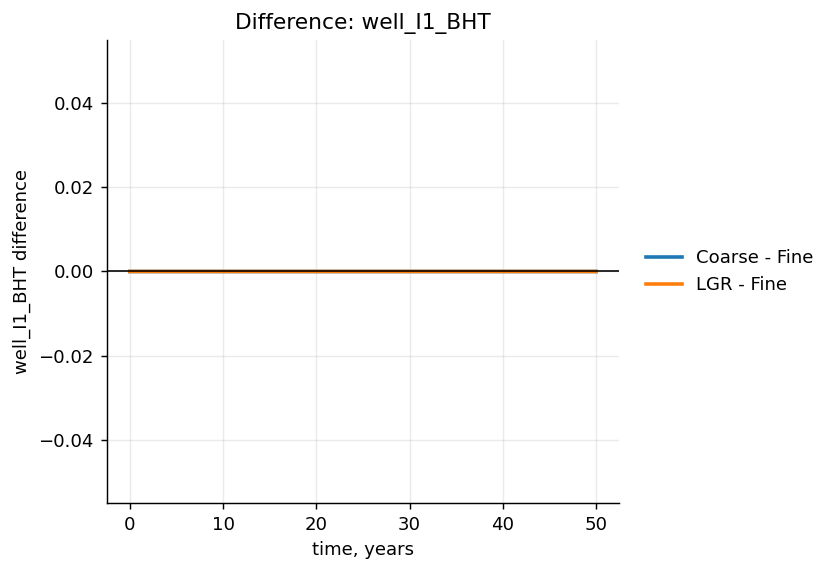

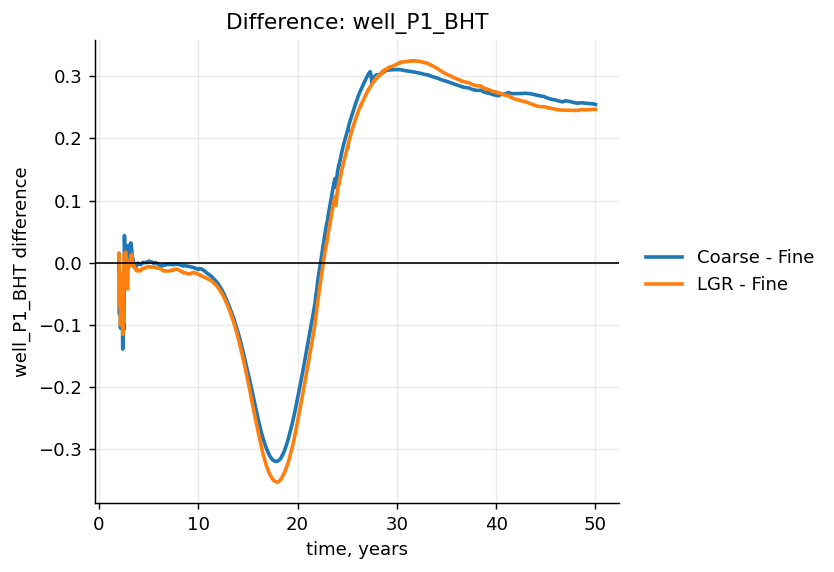

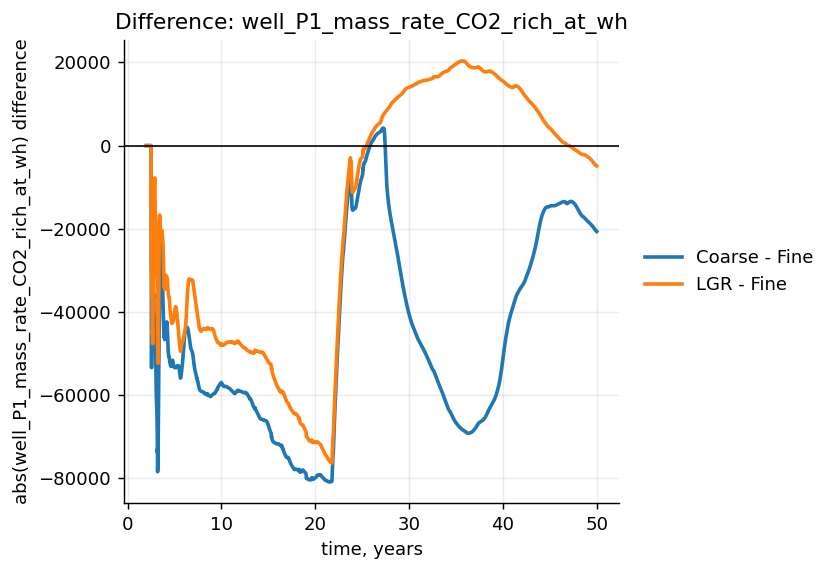

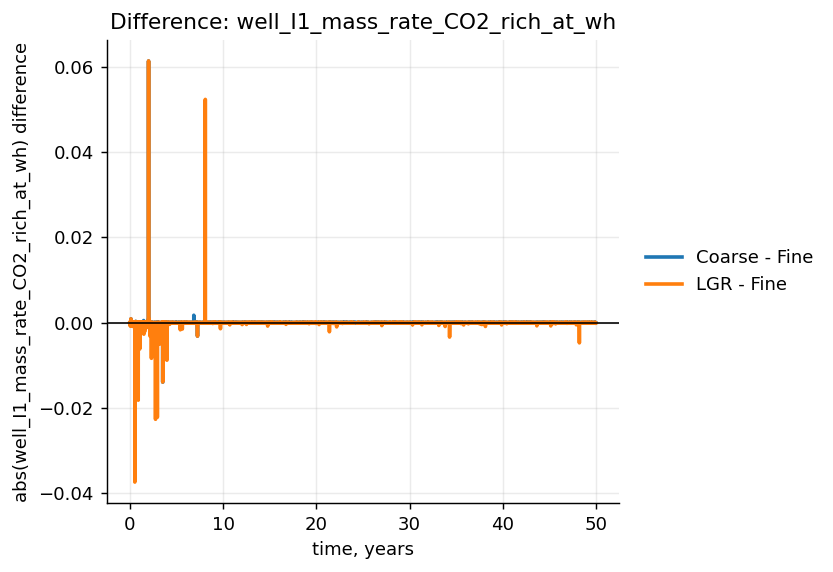

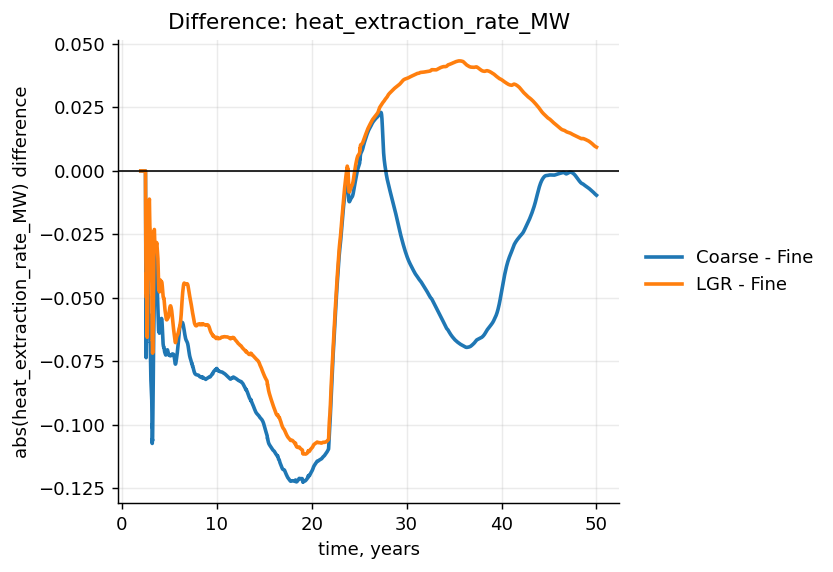

,comparison,case,column,base,max_abs_diff,mean_abs_diff,rmse,max_abs_rel_diff,mean_abs_rel_diff
0,well_I1_BHP,Coarse,well_I1_BHP,Fine,12.942259,0.148422,0.634133,5.989691e-02,7.154665e-04
1,well_I1_BHP,Fine,well_I1_BHP,Fine,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
2,well_I1_BHP,LGR,well_I1_BHP,Fine,2.916350,0.105023,0.227753,1.381147e-02,5.107899e-04
3,well_P1_BHP,Coarse,well_P1_BHP,Fine,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
4,well_P1_BHP,Fine,well_P1_BHP,Fine,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
5,well_P1_BHP,LGR,well_P1_BHP,Fine,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
6,well_I1_BHT,Coarse,well_I1_BHT,Fine,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
7,well_I1_BHT,Fine,well_I1_BHT,Fine,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
8,well_I1_BHT,LGR,well_I1_BHT,Fine,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
9,well_P1_BHT,Coarse,well_P1_BHT,Fine,0.320184,0.194642,0.227138,8.959767e-04,5.483159e-04


In [ ]:
def plot_difference(cases, comparison, base_label=BASE_LABEL, time_scale=1.0, time_label="time"):
    this_base_label = comparison_base_label(comparison, base_label)
    grid, aligned, summary = compare_variable(cases, comparison, this_base_label)
    base = aligned[this_base_label]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for label, y in aligned.items():
        if label == this_base_label:
            continue
        xs, ys = smooth_xy(grid / time_scale, y - base)
        ax.plot(xs, ys, linewidth=2.0, label=f"{label} - {this_base_label}")
    ax.axhline(0.0, color="black", linewidth=0.9)
    ax.set_title(f"Difference: {comparison_name(comparison)}")
    ax.set_xlabel(time_label)
    ax.set_ylabel(f"{display_variable_name(comparison_name(comparison))} difference")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig, summary


def plot_differences(cases, comparisons, base_label=BASE_LABEL, time_scale=1.0, time_label="time"):
    figures = {}
    stats = []
    for comparison in comparisons:
        name = comparison_name(comparison)
        fig, summary = plot_difference(cases, comparison, base_label, time_scale, time_label)
        figures[name] = fig
        stats.append(summary)
        plt.show()
    return figures, pd.concat(stats, ignore_index=True)


difference_figures, stats_df = plot_differences(cases, comparisons, BASE_LABEL, TIME_SCALE, TIME_LABEL)
display(stats_df)


## Overlay One Variable With Difference

Set `FOCUS_COMPARISON` to either an item from `comparisons` or an integer index.


,comparison,case,column,base,max_abs_diff,mean_abs_diff,rmse,max_abs_rel_diff,mean_abs_rel_diff
0,heat_extraction_rate_MW,Coarse,heat_extraction_rate_MW,Fine,0.122600,0.054456,0.066386,1.0,0.028342
1,heat_extraction_rate_MW,Fine,heat_extraction_rate_MW,Fine,0.000000,0.000000,0.000000,0.0,0.000000
2,heat_extraction_rate_MW,LGR,heat_extraction_rate_MW,Fine,0.111569,0.047512,0.055828,1.0,0.024244


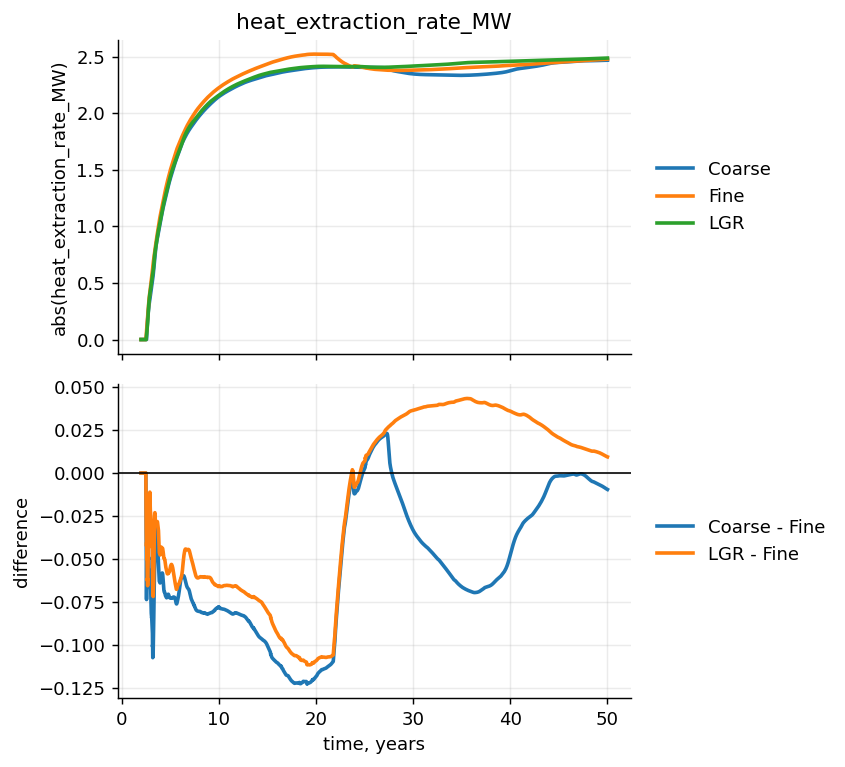

In [ ]:
FOCUS_COMPARISON = -1

focus = comparisons[FOCUS_COMPARISON] if isinstance(FOCUS_COMPARISON, int) else FOCUS_COMPARISON
focus_base_label = comparison_base_label(focus, BASE_LABEL)
grid, aligned, summary = compare_variable(cases, focus, focus_base_label)
base = aligned[focus_base_label]

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for label, case in cases.items():
    column = comparison_column(focus, label)
    x, y = get_series(case, column)
    xs, ys = smooth_xy(x / TIME_SCALE, y)
    axes[0].plot(xs, ys, linewidth=2.0, label=label)
for label, y in aligned.items():
    if label == focus_base_label:
        continue
    xs, ys = smooth_xy(grid / TIME_SCALE, y - base)
    axes[1].plot(xs, ys, linewidth=2.0, label=f"{label} - {focus_base_label}")
axes[1].axhline(0.0, color="black", linewidth=0.9)
axes[0].set_title(comparison_name(focus))
axes[0].set_ylabel(display_variable_name(comparison_name(focus)))
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
axes[1].set_xlabel(TIME_LABEL)
axes[1].set_ylabel("difference")
axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
fig.tight_layout(rect=(0, 0, 0.82, 1))
display(summary)


## CO2 Injection Temperature From CoolProp

This block estimates the CO2 temperature at reservoir pressure from a known liquid-CO2 surface state. Because the initial condition can be close to the saturation boundary, the surface entropy calculation explicitly imposes the liquid branch in CoolProp. The path below is still an ideal isentropic endpoint calculation, not a full wellbore heat-transfer model.


In [ ]:
# ===== CO2 injection temperature estimate =====
# Goal: liquid CO2 surface pressure + surface temperature + reservoir pressure
#       -> ideal isentropic endpoint temperature at reservoir pressure.
# This is not a full wellbore temperature model; it neglects depth, heat exchange, friction, and flow rate.
# Units: pressure in bar, temperature in K.
SURFACE_PRESSURE_BAR = 60.0
SURFACE_TEMPERATURE_K = 295.15
RESERVOIR_PRESSURE_BAR = 50.5
CO2_FLUID_NAME = "CO2"
IMPOSE_SURFACE_LIQUID_PHASE = True


def require_coolprop():
    if PropsSI is None:
        raise ImportError(
            "CoolProp is required for this block. Install it in the notebook kernel with: pip install CoolProp"
        )


def co2_phase(pressure_bar, temperature_k):
    require_coolprop()
    return PhaseSI("P", pressure_bar * 1e5, "T", temperature_k, CO2_FLUID_NAME)


def co2_entropy_kj_per_kg_k(pressure_bar, temperature_k, impose_liquid=False):
    require_coolprop()
    pressure_key = "P|liquid" if impose_liquid else "P"
    return PropsSI("S", pressure_key, pressure_bar * 1e5, "T", temperature_k, CO2_FLUID_NAME) / 1000.0


def co2_temperature_from_entropy_and_pressure_k(entropy_kj_per_kg_k, pressure_bar):
    require_coolprop()
    return PropsSI("T", "P", pressure_bar * 1e5, "S", entropy_kj_per_kg_k * 1000.0, CO2_FLUID_NAME)


def reservoir_temperature_from_liquid_surface_condition(
    surface_pressure_bar,
    surface_temperature_k,
    reservoir_pressure_bar,
):
    surface_entropy_kj_per_kg_k = co2_entropy_kj_per_kg_k(
        surface_pressure_bar,
        surface_temperature_k,
        impose_liquid=IMPOSE_SURFACE_LIQUID_PHASE,
    )
    reservoir_temperature_k = co2_temperature_from_entropy_and_pressure_k(
        surface_entropy_kj_per_kg_k,
        reservoir_pressure_bar,
    )
    return reservoir_temperature_k, surface_entropy_kj_per_kg_k


critical_pressure_bar = PropsSI("Pcrit", CO2_FLUID_NAME) / 1e5
critical_temperature_k = PropsSI("Tcrit", CO2_FLUID_NAME)
reservoir_temperature_k, surface_entropy_kj_per_kg_k = reservoir_temperature_from_liquid_surface_condition(
    SURFACE_PRESSURE_BAR,
    SURFACE_TEMPERATURE_K,
    RESERVOIR_PRESSURE_BAR,
)

surface_phase = co2_phase(SURFACE_PRESSURE_BAR, SURFACE_TEMPERATURE_K)
reservoir_phase = co2_phase(RESERVOIR_PRESSURE_BAR, reservoir_temperature_k)

print("Assumption: ideal isentropic path from liquid-CO2 surface condition to reservoir pressure")
print("Interpretation: reversible adiabatic endpoint, not a full wellbore temperature prediction")
print(f"CO2 critical point: Pcrit={critical_pressure_bar:.3f} bar, Tcrit={critical_temperature_k:.2f} K ({critical_temperature_k - 273.15:.2f} degC)")
print(f"Surface condition: P={SURFACE_PRESSURE_BAR:.3f} bar, T={SURFACE_TEMPERATURE_K:.2f} K ({SURFACE_TEMPERATURE_K - 273.15:.2f} degC)")
print(f"Surface phase from CoolProp: {surface_phase}")
print(f"Surface entropy branch: {'liquid imposed' if IMPOSE_SURFACE_LIQUID_PHASE else 'automatic'}")
print(f"Conserved entropy: s={surface_entropy_kj_per_kg_k:.6f} kJ/kg/K")
print(f"Reservoir pressure: P={RESERVOIR_PRESSURE_BAR:.3f} bar")
print(
    "Estimated CO2 temperature at reservoir pressure: "
    f"{reservoir_temperature_k:.2f} K ({reservoir_temperature_k - 273.15:.2f} degC)"
)
print(f"Reservoir-pressure endpoint phase from CoolProp: {reservoir_phase}")


Assumption: ideal isentropic path from liquid-CO2 surface condition to reservoir pressure
Interpretation: reversible adiabatic endpoint, not a full wellbore temperature prediction
CO2 critical point: Pcrit=73.773 bar, Tcrit=304.13 K (30.98 degC)
Surface condition: P=60.000 bar, T=295.15 K (22.00 degC)
Surface phase from CoolProp: gas
Surface entropy branch: liquid imposed
Conserved entropy: s=1.210608 kJ/kg/K
Reservoir pressure: P=50.500 bar
Estimated CO2 temperature at reservoir pressure: 287.85 K (14.70 degC)
Reservoir-pressure endpoint phase from CoolProp: unknown: Saturation pressure [5.05e+06 Pa] corresponding to T [287.846 K] is within 1e-4 % of given p [5.05e+06 Pa] : PropsSI("Phase","P",5050000,"T",287.8459286,"CO2")


## P90/P50/P10 Across Realizations

读取 `PERM*_ECL/well_time_data.xlsx`，复用上面已有的 `add_heat_extraction_rate(...)` 计算 Q，然后按最终时刻的 Q 选取并标注 P90/P50/P10 realization。

In [ ]:
# ===== Realization ensemble Q plot =====
REALIZATION_RESULTS_ROOT = Path(r"E:\\100 realizations\\results_closed_83c")
REALIZATION_GLOB = "PERM*_ECL"
REALIZATION_EXCEL_NAME = "well_time_data.xlsx"
REALIZATION_SKIP_INITIAL_TIME_STEPS = 20

REALIZATION_VARIABLES = [
    "well_I1_BHP",
    "well_P1_BHT",
    "well_P1_mass_rate_LCO2_at_wh",
    HEAT_EXTRACTION_COLUMN,
]

# Select P90/P50/P10 by the final value of this column.
# Use I1 BHP as the realization ranking metric.
PERCENTILE_METRIC_COLUMN = "well_I1_BHP"
PERCENTILE_P_CONVENTION = "reservoir"  # reservoir: P90=10th percentile, P10=90th percentile

# Optional: also create cumulative heat energy from Q [MW].
# MW * day * 24 = MWh.
REALIZATION_CUMULATIVE_Q_COLUMN = "cumulative_heat_MWh"
REALIZATION_OUTPUT_FIGURE = REALIZATION_RESULTS_ROOT / "Q_realizations_P90_P50_P10.png"
REALIZATION_VARIABLES_OUTPUT_FIGURE = REALIZATION_RESULTS_ROOT / "realization_variables_P90_P50_P10.png"


def realization_excel_specs(results_root, realization_glob="PERM*_ECL", excel_name="well_time_data.xlsx"):
    results_root = Path(results_root)
    specs = []
    for case_dir in sorted(results_root.glob(realization_glob), key=natural_sort_key):
        if not case_dir.is_dir():
            continue
        path = case_dir / excel_name
        if path.exists():
            specs.append({"label": case_dir.name, "path": path, "sheet_name": 0})
    if not specs:
        raise FileNotFoundError(f"No realization Excel files found under {results_root}")
    return specs


def add_cumulative_heat_energy(df, time_col, q_col=HEAT_EXTRACTION_COLUMN, out_col=REALIZATION_CUMULATIVE_Q_COLUMN):
    df = df.copy()
    time = pd.to_numeric(df[time_col], errors="coerce").to_numpy(dtype=float)
    q_mw = pd.to_numeric(df[q_col], errors="coerce").to_numpy(dtype=float)
    cumulative = np.zeros_like(q_mw, dtype=float)
    valid = np.isfinite(time) & np.isfinite(q_mw)
    if np.count_nonzero(valid) > 1:
        order = np.argsort(time[valid])
        valid_idx = np.flatnonzero(valid)[order]
        t = time[valid_idx]
        q = q_mw[valid_idx]
        cumulative_valid = np.zeros_like(q, dtype=float)
        cumulative_valid[1:] = np.cumsum(0.5 * (q[1:] + q[:-1]) * np.diff(t) * 24.0)
        cumulative[valid_idx] = cumulative_valid
    df[out_col] = cumulative
    return df


def load_realization_q_cases(specs, time_column=None, skip_initial_steps=0):
    cases = {}
    for spec in specs:
        label = spec["label"]
        path = Path(spec["path"])
        df = clean_columns(read_table(path, spec.get("sheet_name", 0)))
        tcol = find_time_column(df, time_column)
        df[tcol] = pd.to_numeric(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol]).sort_values(tcol).drop_duplicates(subset=[tcol], keep="last")
        skip_count = steps_to_skip(skip_initial_steps, label)
        if skip_count:
            df = df.iloc[skip_count:]
        if df.empty:
            raise ValueError(f"No rows left for {label!r} after skipping {skip_count} initial time steps")
        df = add_heat_extraction_rate(df, path)
        df = add_cumulative_heat_energy(df, tcol)
        cases[label] = {"df": df, "time_col": tcol, "path": path}
    return cases


def final_metric_table(cases, metric_column):
    rows = []
    for label, case in cases.items():
        df = case["df"]
        if metric_column not in df.columns:
            raise KeyError(f"{metric_column!r} not found for {label}")
        y = pd.to_numeric(df[metric_column], errors="coerce")
        valid = y[np.isfinite(y)]
        rows.append({
            "realization": label,
            "final_metric": float(valid.iloc[-1]) if len(valid) else np.nan,
            "path": str(case["path"]),
        })
    return pd.DataFrame(rows).sort_values("realization", key=lambda s: s.map(natural_sort_key)).reset_index(drop=True)


def percentile_realizations(metric_df, convention="reservoir"):
    clean = metric_df.dropna(subset=["final_metric"]).copy()
    if clean.empty:
        raise ValueError("No finite final_metric values found")
    percentile_map = {"P90": 10.0, "P50": 50.0, "P10": 90.0}
    if convention != "reservoir":
        percentile_map = {"P90": 90.0, "P50": 50.0, "P10": 10.0}
    rows = []
    values = clean["final_metric"].to_numpy(dtype=float)
    for label, percentile in percentile_map.items():
        target = float(np.nanpercentile(values, percentile))
        idx = (clean["final_metric"] - target).abs().idxmin()
        row = clean.loc[idx]
        rows.append({
            "label": label,
            "percentile": percentile,
            "target_metric": target,
            "realization": row["realization"],
            "realization_metric": float(row["final_metric"]),
        })
    return pd.DataFrame(rows)


def plot_realization_percentiles(cases, percentile_df, metric_column, time_scale=TIME_SCALE, time_label=TIME_LABEL):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for label, case in cases.items():
        x, y = get_series(case, metric_column)
        xs, ys = smooth_xy(x / time_scale, y)
        ax.plot(xs, ys, color="0.72", linewidth=0.8, alpha=0.55, zorder=1)

    styles = {
        "P90": {"color": "#1f77b4", "linewidth": 2.4},
        "P50": {"color": "#2ca02c", "linewidth": 2.6},
        "P10": {"color": "#d62728", "linewidth": 2.4},
    }
    for _, row in percentile_df.iterrows():
        label = row["label"]
        realization = row["realization"]
        x, y = get_series(cases[realization], metric_column)
        xs, ys = smooth_xy(x / time_scale, y)
        ax.plot(
            xs,
            ys,
            label=f"{label}: {realization} ({row['realization_metric']:.4g})",
            zorder=3,
            **styles[label],
        )
        ax.scatter(xs[-1], ys[-1], color=styles[label]["color"], s=30, zorder=4)
        ax.annotate(
            f"{label}\n{realization}",
            xy=(xs[-1], ys[-1]),
            xytext=(8, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
            color=styles[label]["color"],
        )

    ax.set_xlabel(time_label)
    ax.set_ylabel(display_variable_name(metric_column))
    ax.set_title(f"{metric_column}: 101 realizations with P90/P50/P10")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig


def plot_realization_variable_grid(cases, variables, percentile_df, time_scale=TIME_SCALE, time_label=TIME_LABEL):
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(9, max(3.0, 2.8 * n)), squeeze=False)
    styles = {
        "P90": {"color": "#1f77b4", "linewidth": 2.2},
        "P50": {"color": "#2ca02c", "linewidth": 2.4},
        "P10": {"color": "#d62728", "linewidth": 2.2},
    }

    for ax, variable in zip(axes.ravel(), variables):
        for case in cases.values():
            x, y = get_series(case, variable)
            xs, ys = smooth_xy(x / time_scale, y)
            ax.plot(xs, ys, color="0.72", linewidth=0.75, alpha=0.5, zorder=1)

        for _, row in percentile_df.iterrows():
            label = row["label"]
            realization = row["realization"]
            x, y = get_series(cases[realization], variable)
            xs, ys = smooth_xy(x / time_scale, y)
            ax.plot(xs, ys, label=f"{label}: {realization}", zorder=3, **styles[label])

        ax.set_title(display_variable_name(variable))
        ax.set_xlabel(time_label)
        ax.set_ylabel(display_variable_name(variable))
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

    fig.tight_layout(rect=(0, 0, 0.82, 1))
    return fig


realization_specs = realization_excel_specs(REALIZATION_RESULTS_ROOT, REALIZATION_GLOB, REALIZATION_EXCEL_NAME)
realization_cases = load_realization_q_cases(realization_specs, TIME_COLUMN, REALIZATION_SKIP_INITIAL_TIME_STEPS)
realization_metric_df = final_metric_table(realization_cases, PERCENTILE_METRIC_COLUMN)
realization_percentile_df = percentile_realizations(realization_metric_df, PERCENTILE_P_CONVENTION)

display(realization_percentile_df)
fig = plot_realization_percentiles(realization_cases, realization_percentile_df, PERCENTILE_METRIC_COLUMN)
fig.savefig(REALIZATION_OUTPUT_FIGURE, bbox_inches="tight")
fig_vars = plot_realization_variable_grid(realization_cases, REALIZATION_VARIABLES, realization_percentile_df)
fig_vars.savefig(REALIZATION_VARIABLES_OUTPUT_FIGURE, bbox_inches="tight")
print(f"Loaded {len(realization_cases)} realizations")
print(f"Skipped first {REALIZATION_SKIP_INITIAL_TIME_STEPS} time steps per realization")
print(f"Saved figure to: {REALIZATION_OUTPUT_FIGURE}")
print(f"Saved variable comparison figure to: {REALIZATION_VARIABLES_OUTPUT_FIGURE}")


KeyError: "Missing columns in well_time_data.xlsx: ['well_P1_mass_rate_CO2_rich_at_wh']. Available columns: ['time', 'well_I1_BHP', 'well_I1_BHT', 'well_P1_BHP', 'well_P1_BHT', 'well_I1_perf_0_molar_rate_V', 'well_I1_perf_0_molar_rate_LCO2', 'well_I1_perf_1_molar_rate_V', 'well_I1_perf_1_molar_rate_LCO2', 'well_I1_perf_2_molar_rate_V', 'well_I1_perf_2_molar_rate_LCO2', 'well_I1_perf_3_molar_rate_V', 'well_I1_perf_3_molar_rate_LCO2', 'well_I1_perf_4_molar_rate_V', 'well_I1_perf_4_molar_rate_LCO2', 'well_I1_perf_5_molar_rate_V', 'well_I1_perf_5_molar_rate_LCO2', 'well_I1_perf_6_molar_rate_V', 'well_I1_perf_6_molar_rate_LCO2', 'well_P1_perf_0_molar_rate_V', 'well_P1_perf_0_molar_rate_LCO2', 'well_P1_perf_1_molar_rate_V', 'well_P1_perf_1_molar_rate_LCO2', 'well_P1_perf_2_molar_rate_V', 'well_P1_perf_2_molar_rate_LCO2', 'well_P1_perf_3_molar_rate_V', 'well_P1_perf_3_molar_rate_LCO2', 'well_P1_perf_4_molar_rate_V', 'well_P1_perf_4_molar_rate_LCO2', 'well_P1_perf_5_molar_rate_V', 'well_P1_per

## Sensitivity Analysis Cases

?? 500m/1000m/2000m case list ?? `well_time_data.xlsx`???????? `add_heat_extraction_rate(...)` ?? Q???? depth?horizontal permeability?kv/kh?injection rate ?????????? shallow ?? `S_17C` ???????? 16C??? `SENSITIVITY_SHALLOW_TEMPERATURE`?


Using CO2_rich mass-rate column for S-01 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-01_single_phase_17C\well_time_data.xlsx
Using LCO2 mass-rate column for D-01 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-01\well_time_data.xlsx


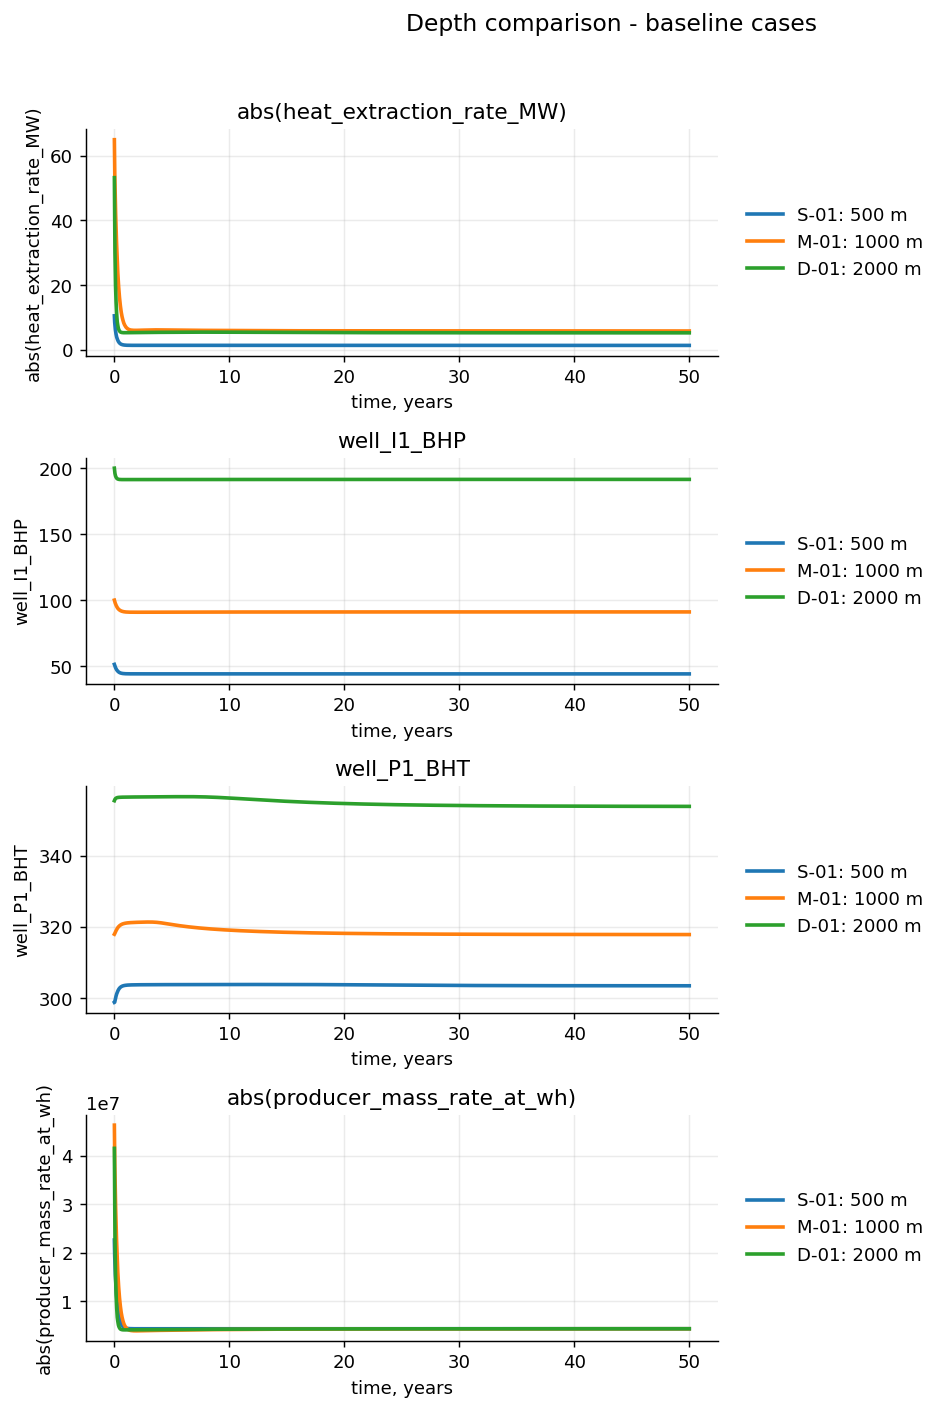

Using CO2_rich mass-rate column for S-05 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-05_single_phase_17C\well_time_data.xlsx
Using LCO2 mass-rate column for D-05 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-05\well_time_data.xlsx


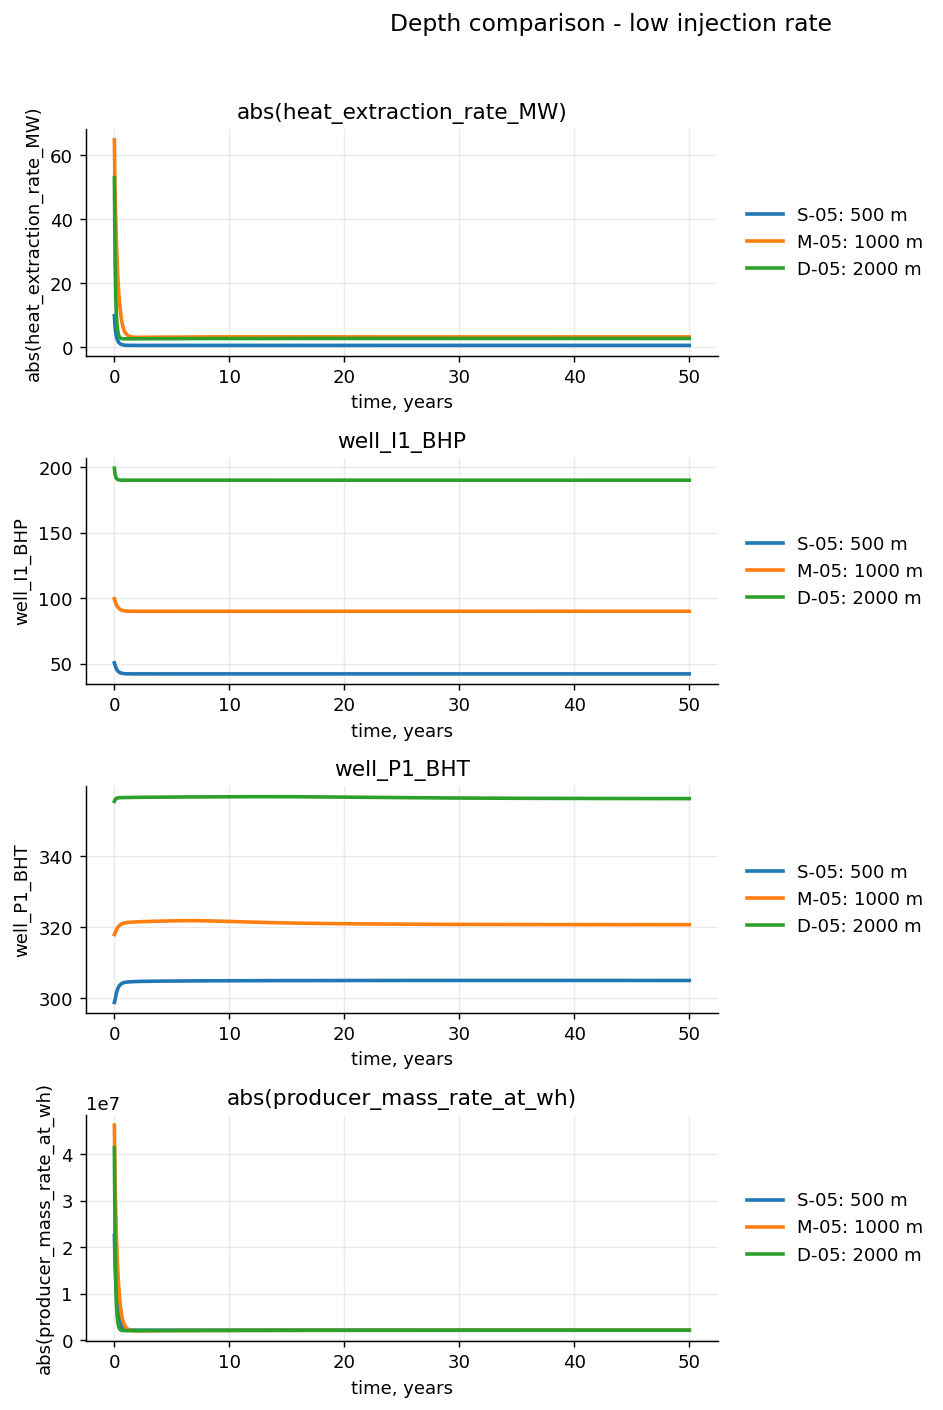

Using CO2_rich mass-rate column for S-06 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-06_single_phase_17C\well_time_data.xlsx
Using LCO2 mass-rate column for D-06 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-06\well_time_data.xlsx


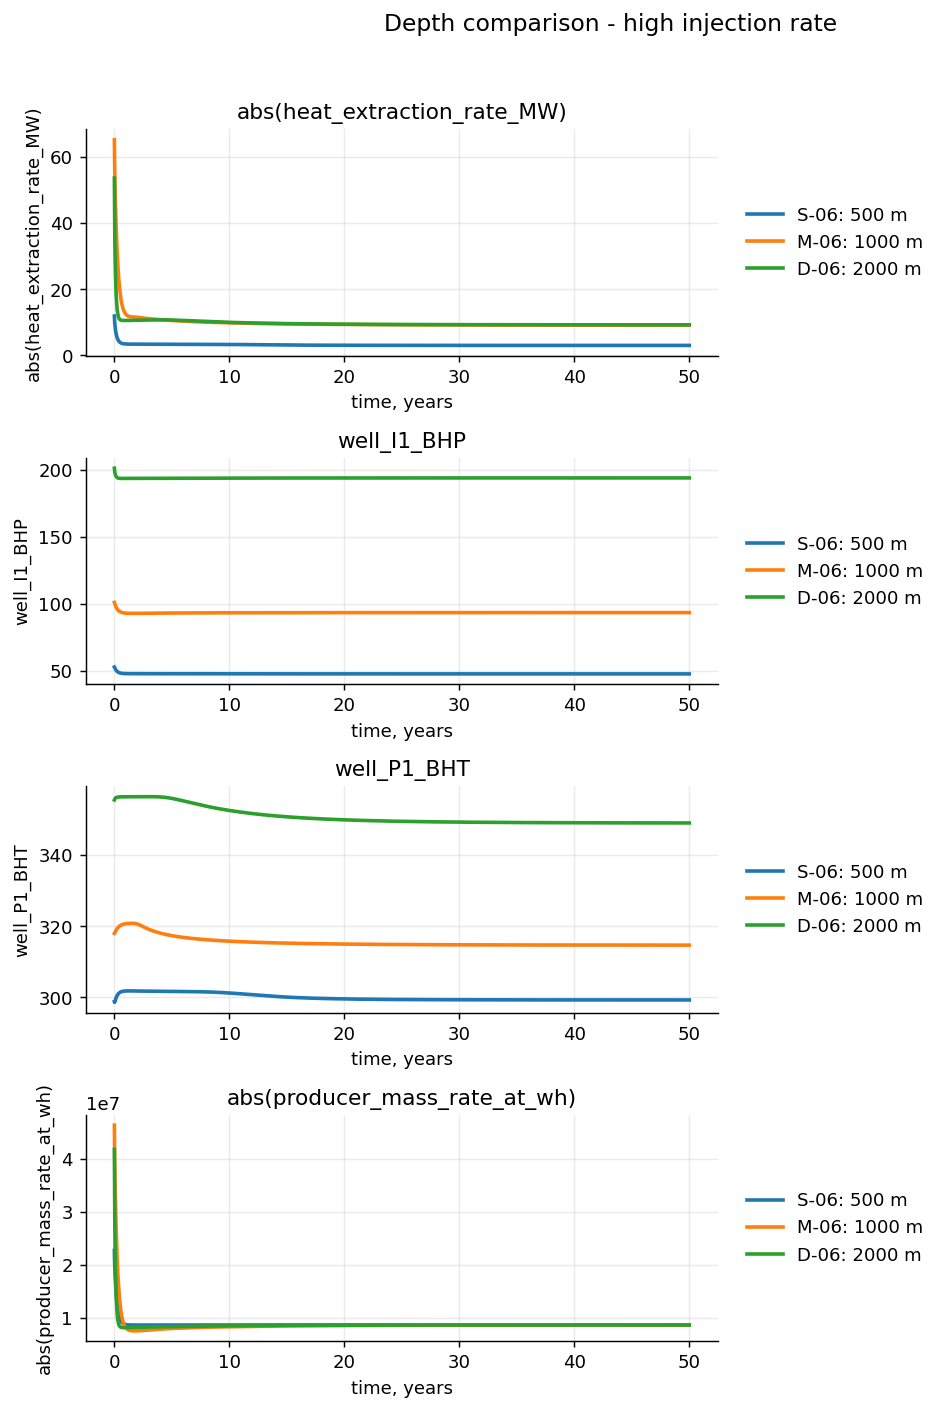

Using CO2_rich mass-rate column for S-02 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-02_single_phase_17C\well_time_data.xlsx
Using LCO2 mass-rate column for D-02 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-02\well_time_data.xlsx


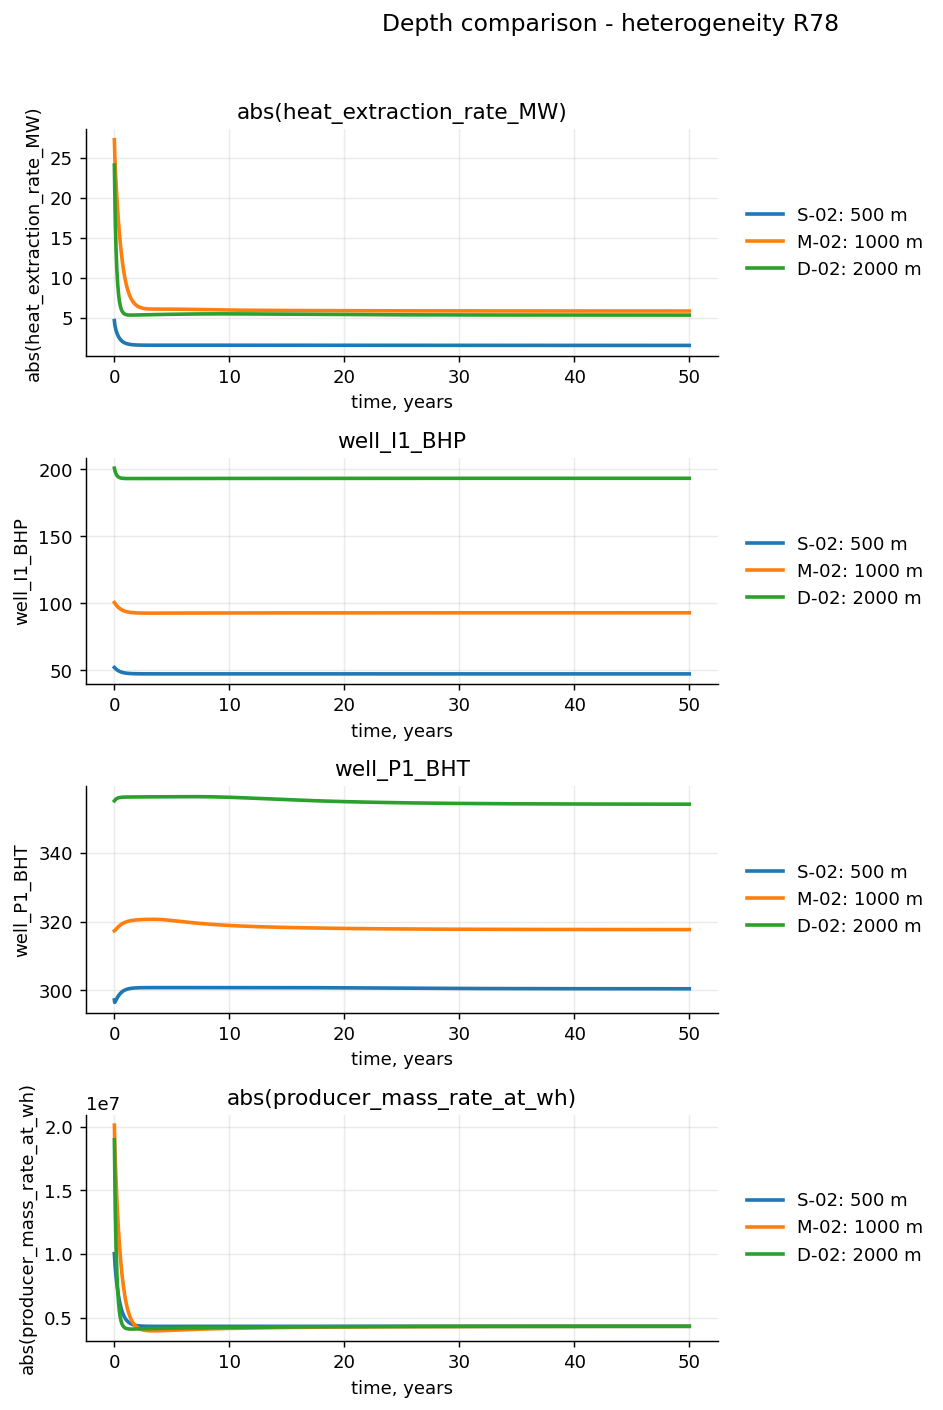

Using CO2_rich mass-rate column for S-03 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-03_single_phase_17C\well_time_data.xlsx
Using LCO2 mass-rate column for D-03 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-03\well_time_data.xlsx


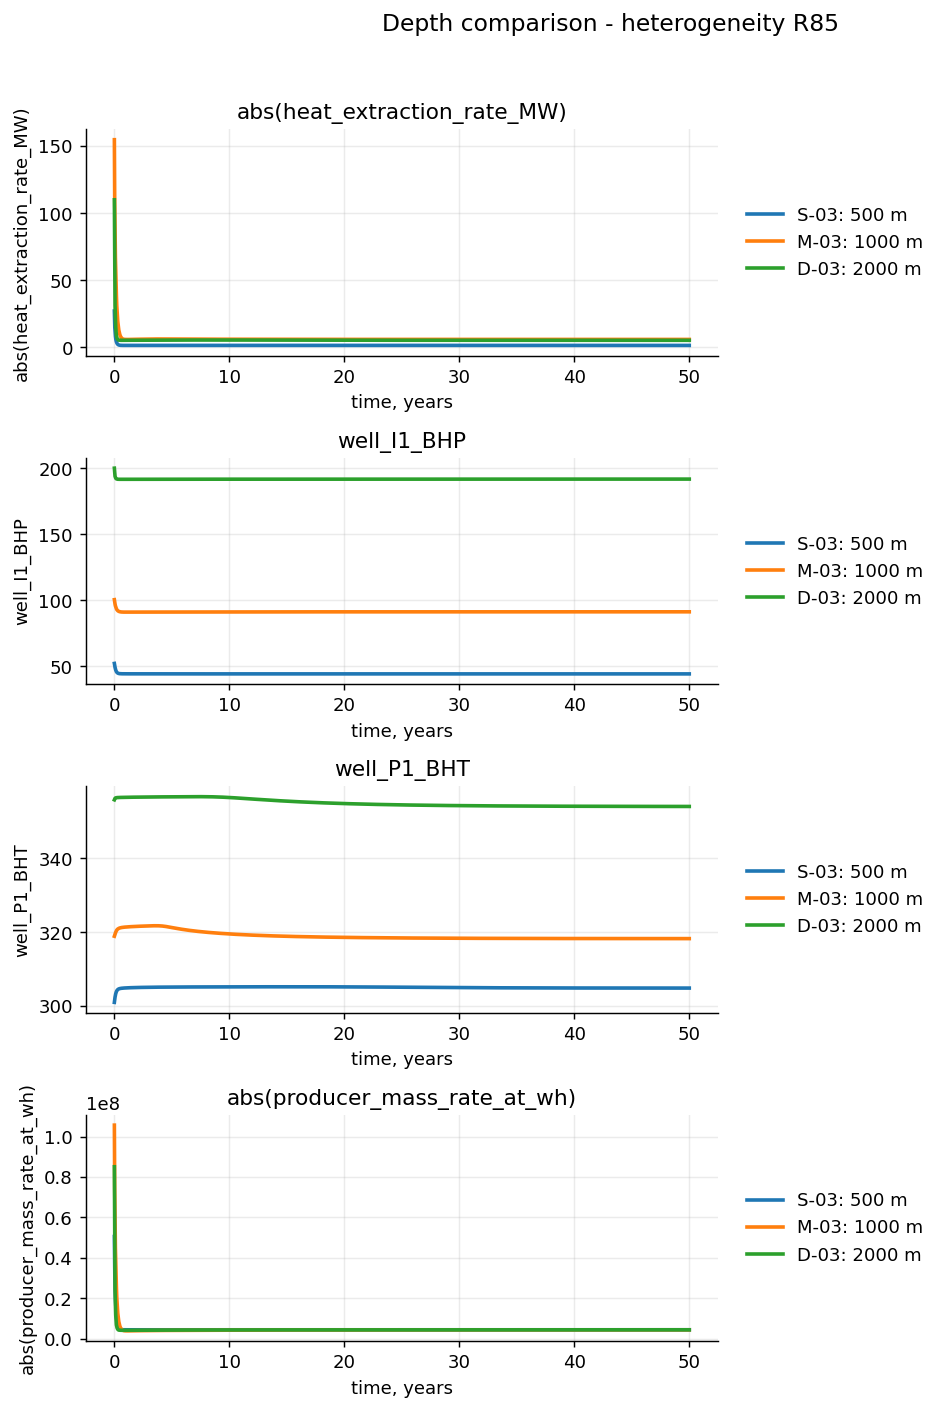

Using CO2_rich mass-rate column for S-04 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-04_single_phase_17C\well_time_data.xlsx
Using LCO2 mass-rate column for D-04 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-04\well_time_data.xlsx


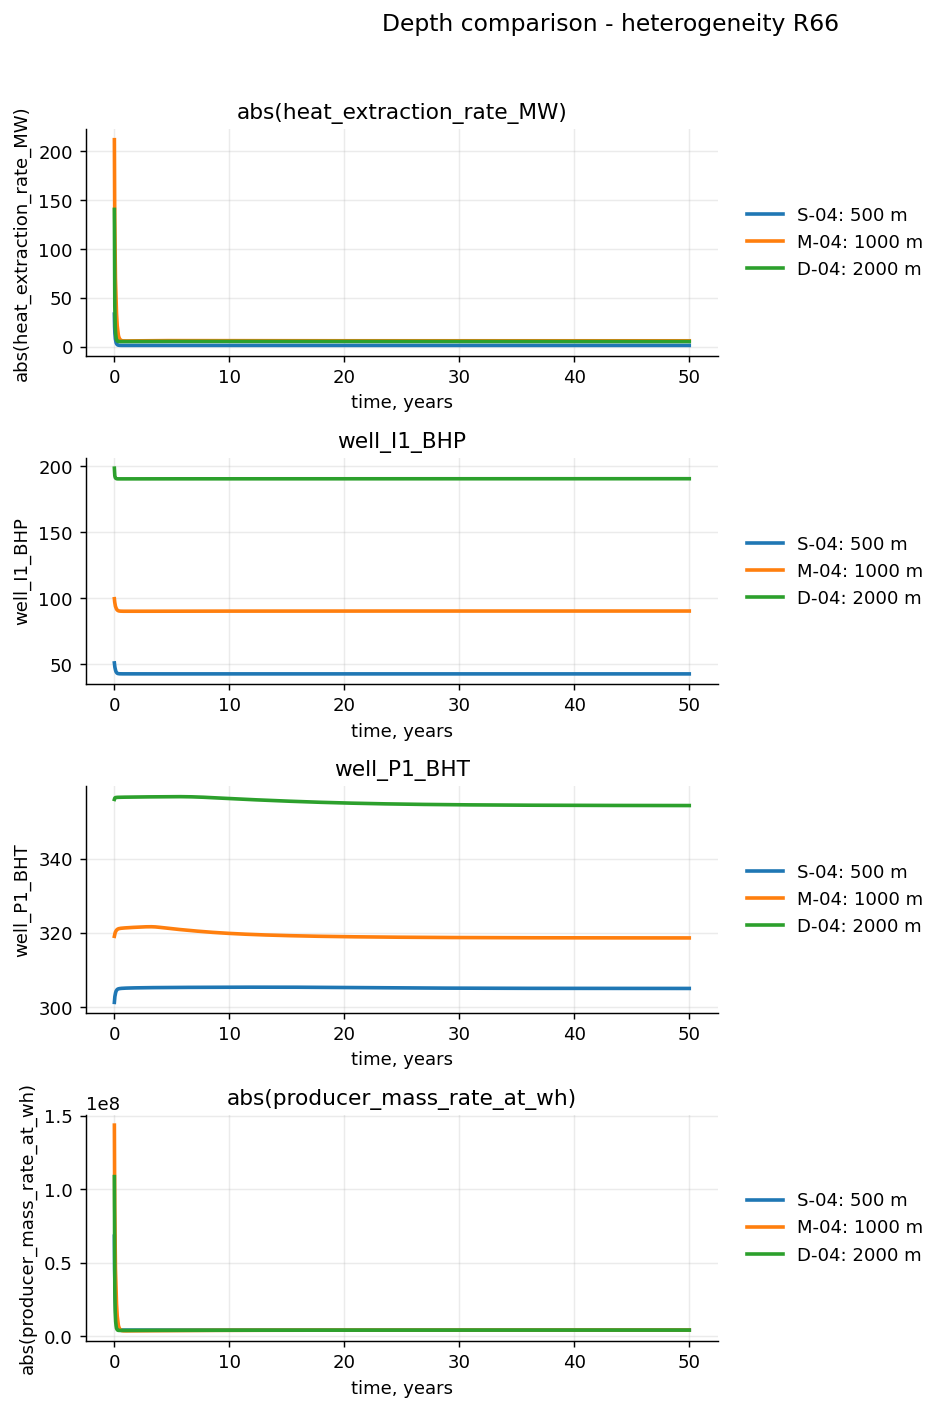

Using CO2_rich mass-rate column for S-07 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-07_single_phase_17C\well_time_data.xlsx
Using LCO2 mass-rate column for D-11 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-11\well_time_data.xlsx


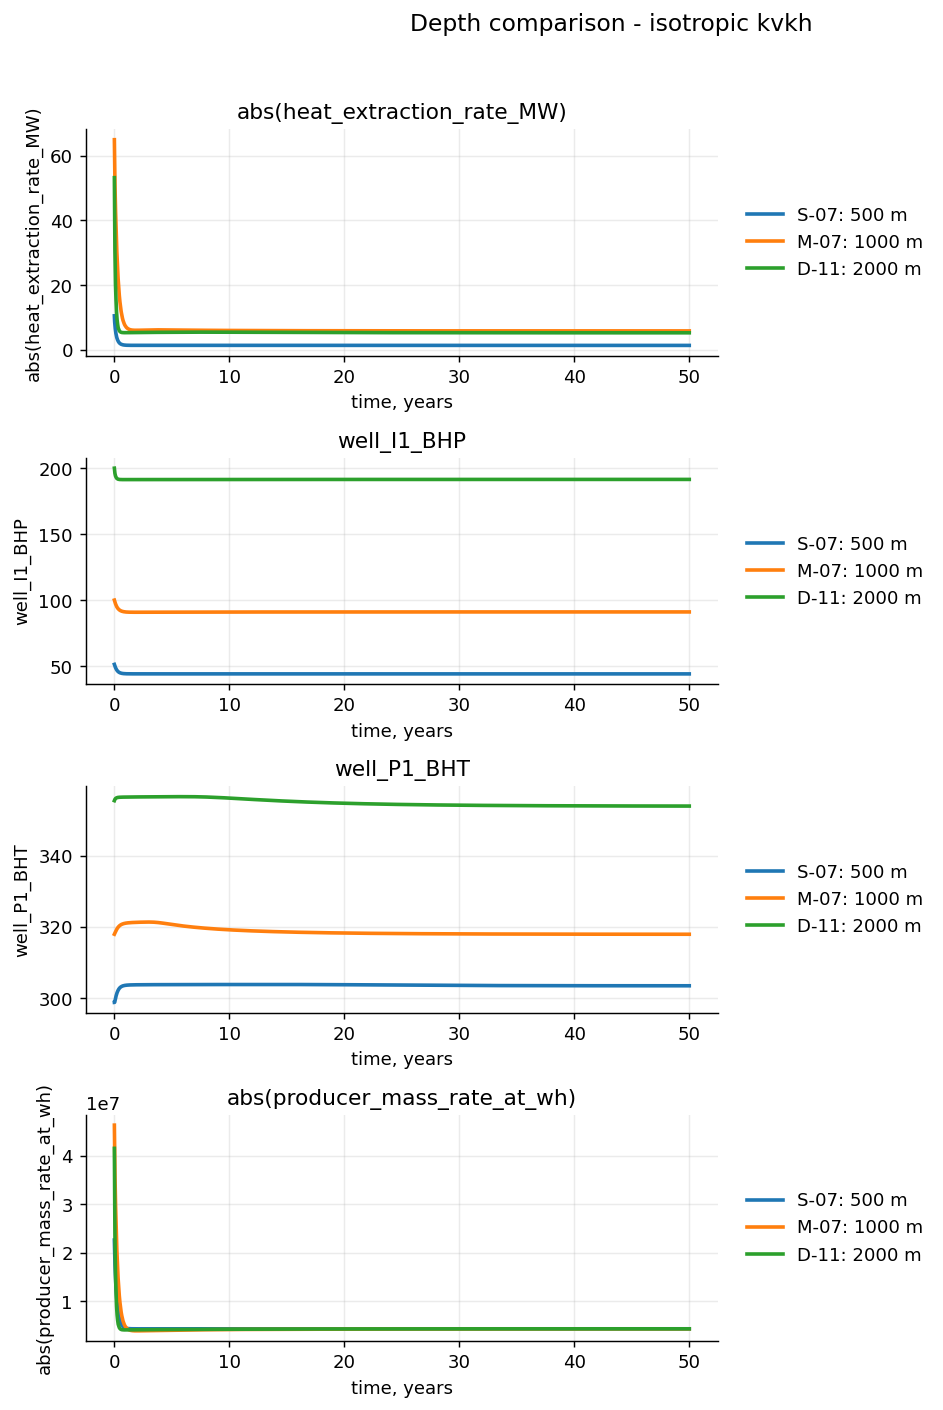

Using LCO2 mass-rate column for D-07 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-07\well_time_data.xlsx
Using LCO2 mass-rate column for D-08 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-08\well_time_data.xlsx
Using LCO2 mass-rate column for D-01 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-01\well_time_data.xlsx
Using LCO2 mass-rate column for D-09 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-09\well_time_data.xlsx


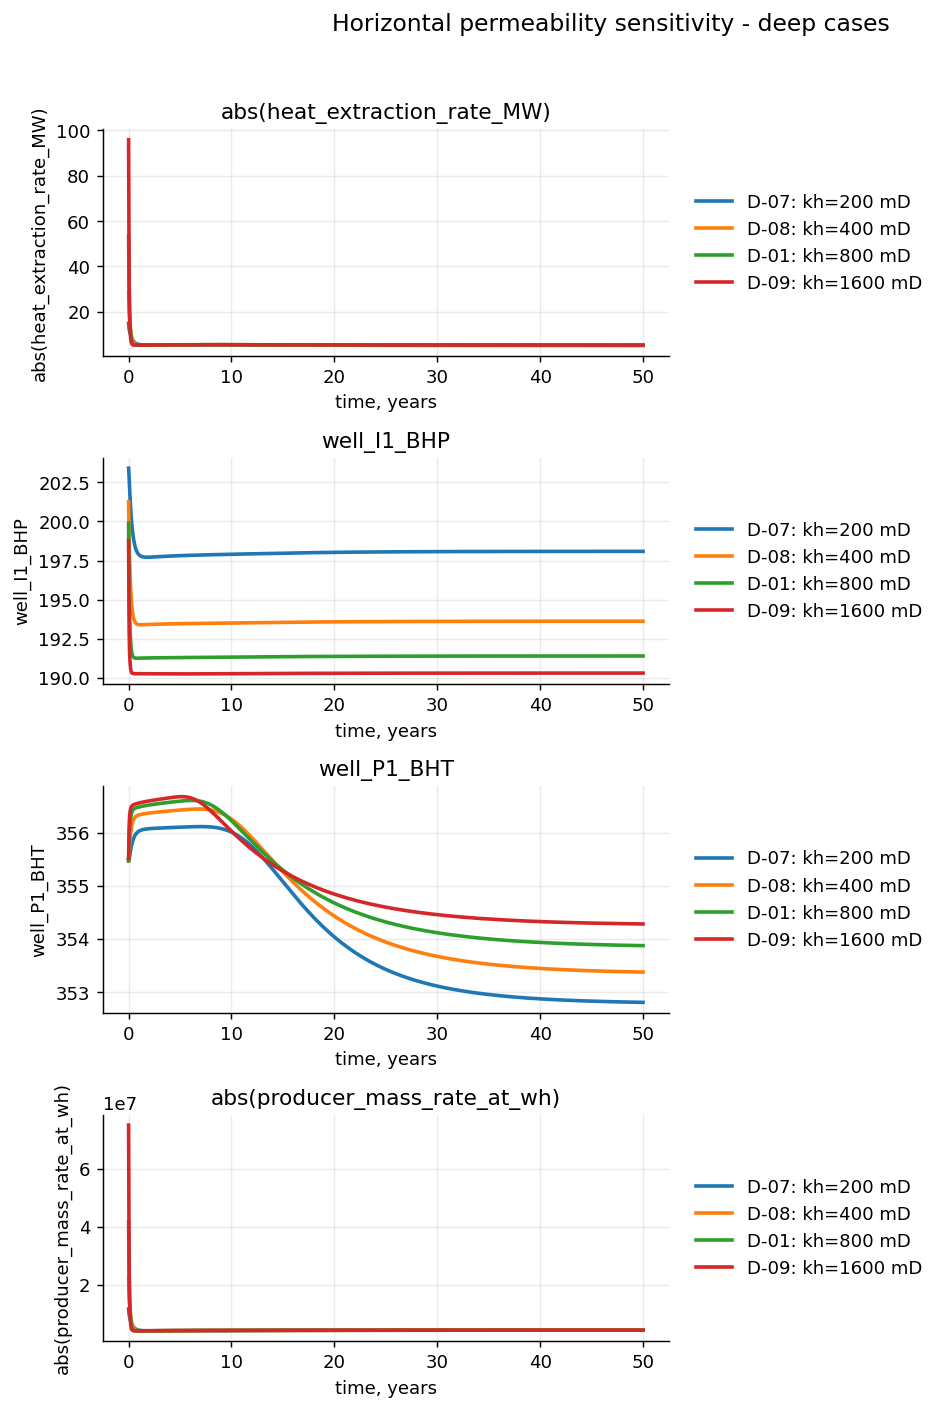

Using CO2_rich mass-rate column for S-01 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-01_single_phase_17C\well_time_data.xlsx
Using CO2_rich mass-rate column for S-07 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-07_single_phase_17C\well_time_data.xlsx


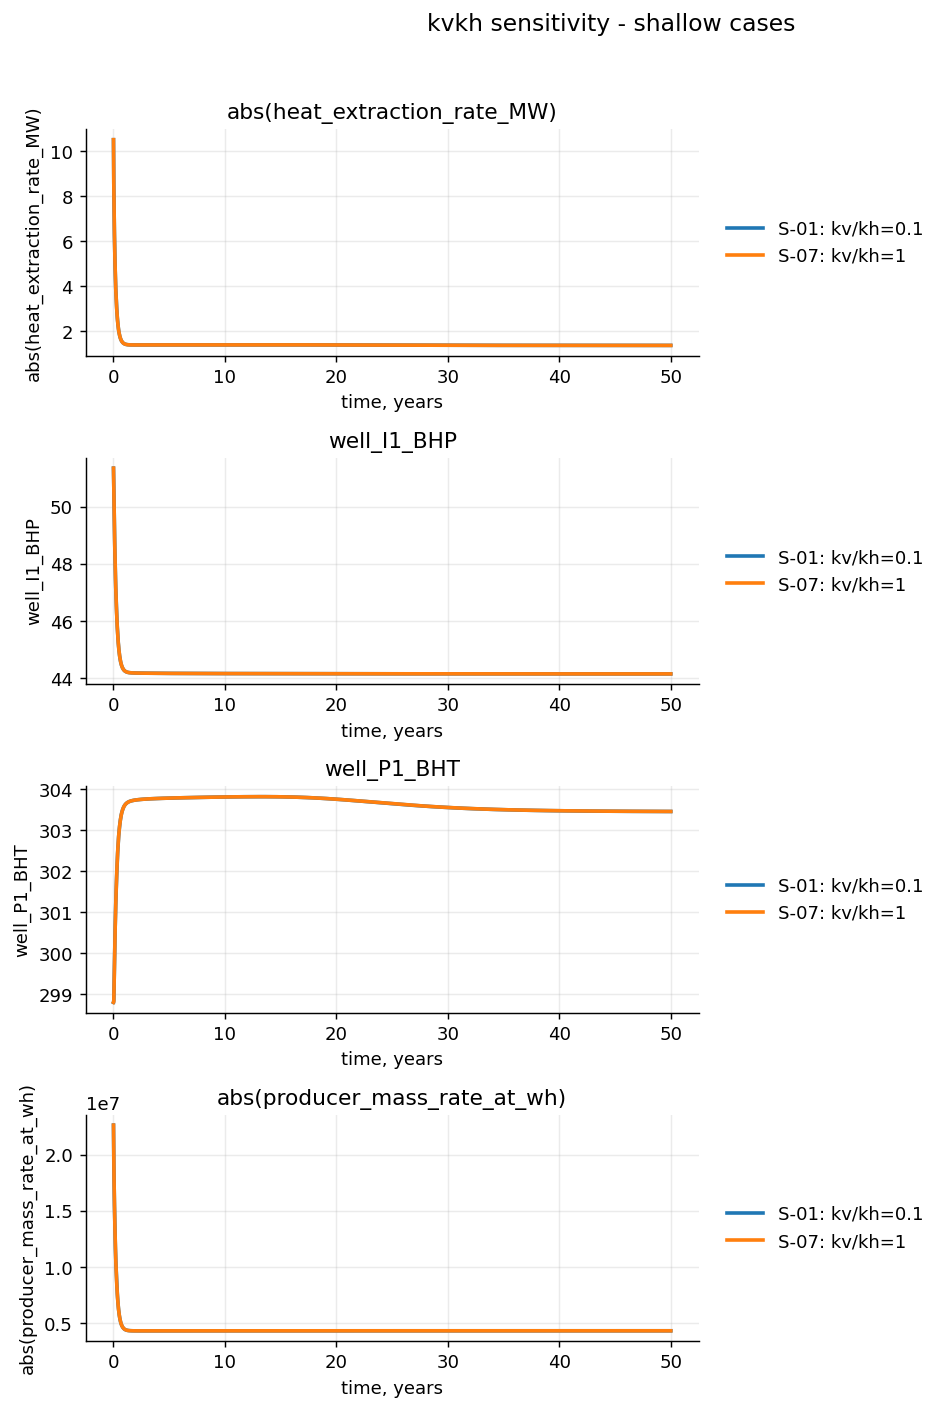

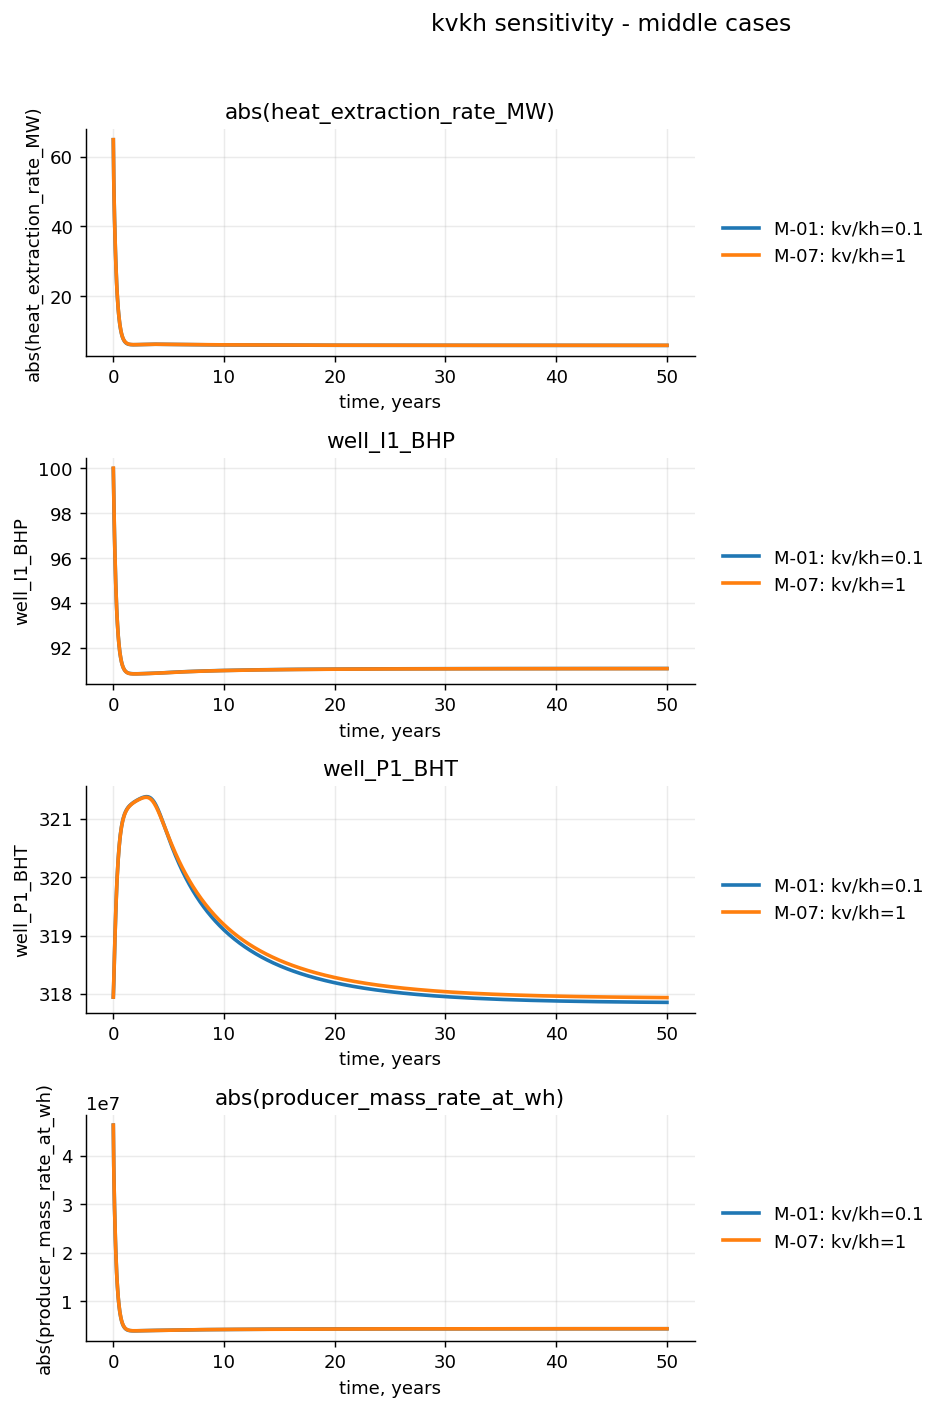

Using LCO2 mass-rate column for D-10 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-10\well_time_data.xlsx
Using LCO2 mass-rate column for D-01 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-01\well_time_data.xlsx
Using LCO2 mass-rate column for D-11 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-11\well_time_data.xlsx


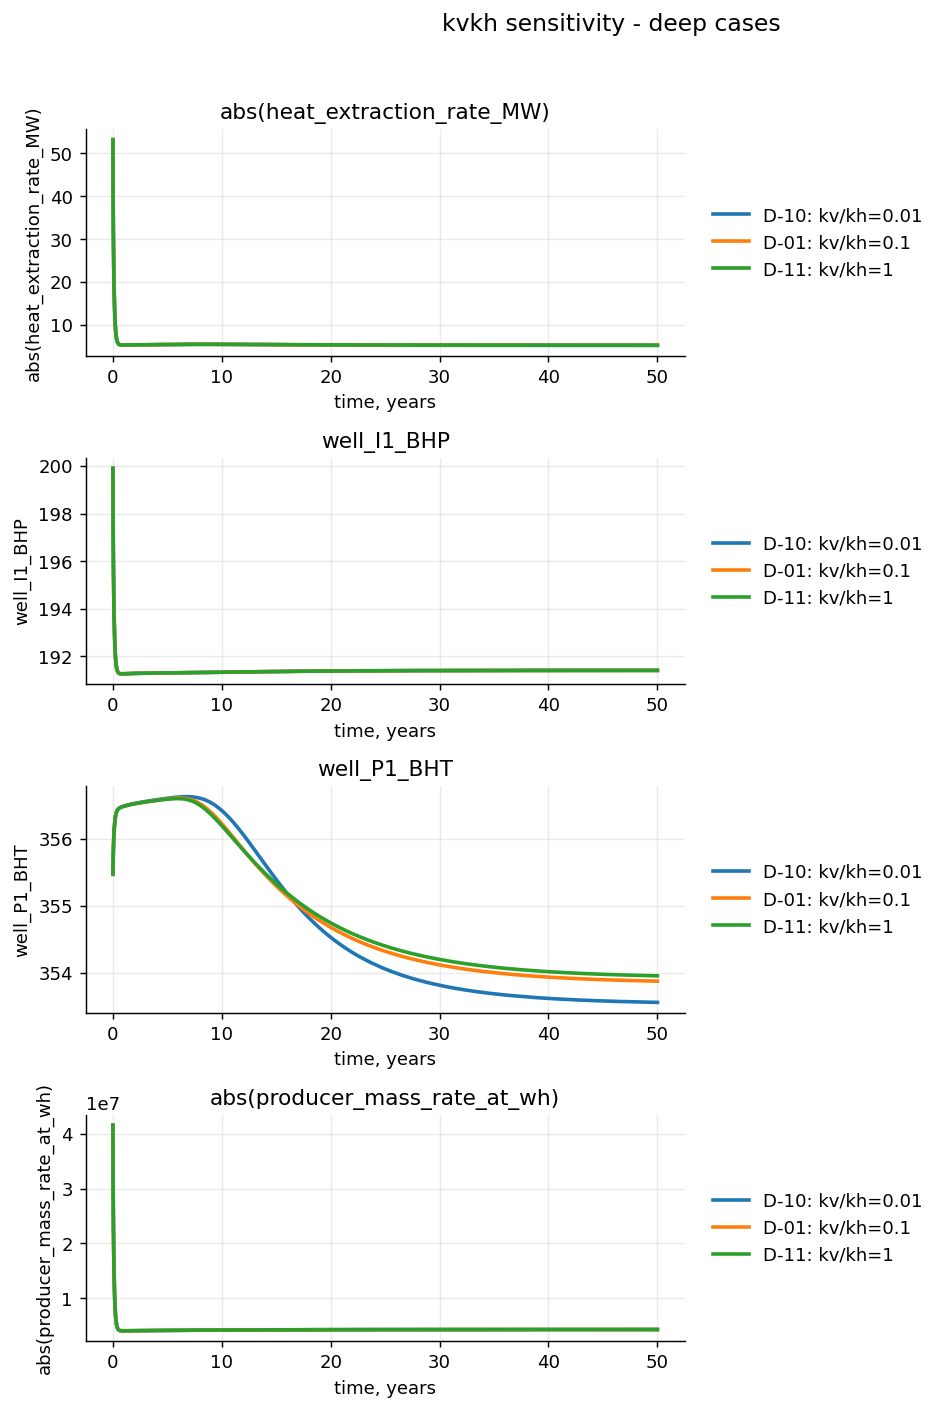

Using CO2_rich mass-rate column for S-05 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-05_single_phase_17C\well_time_data.xlsx
Using CO2_rich mass-rate column for S-01 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-01_single_phase_17C\well_time_data.xlsx
Using CO2_rich mass-rate column for S-06 because LCO2 is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\S_17C\S-06_single_phase_17C\well_time_data.xlsx


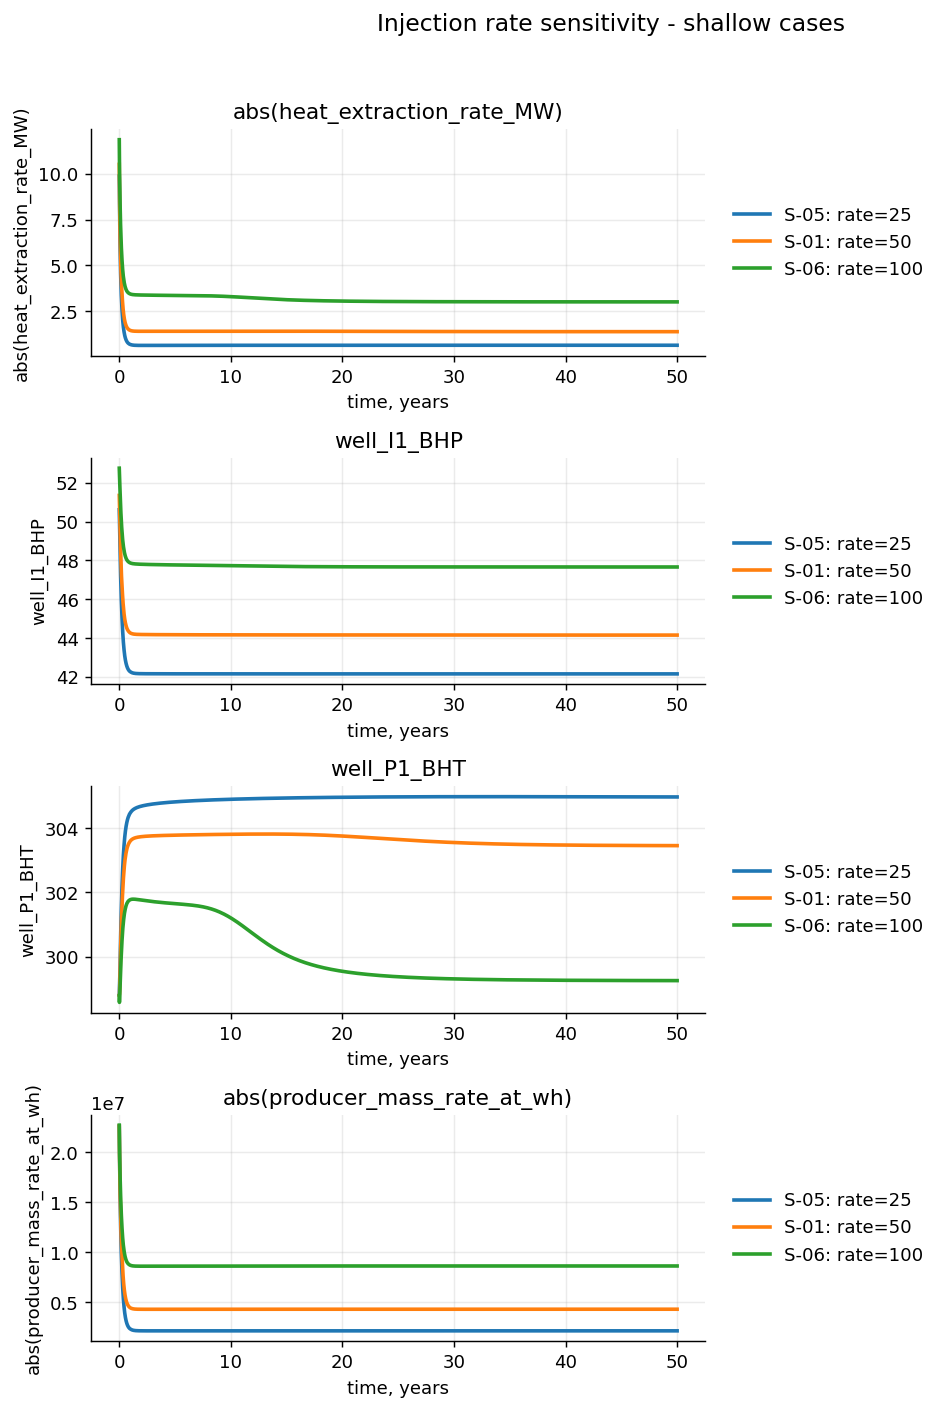

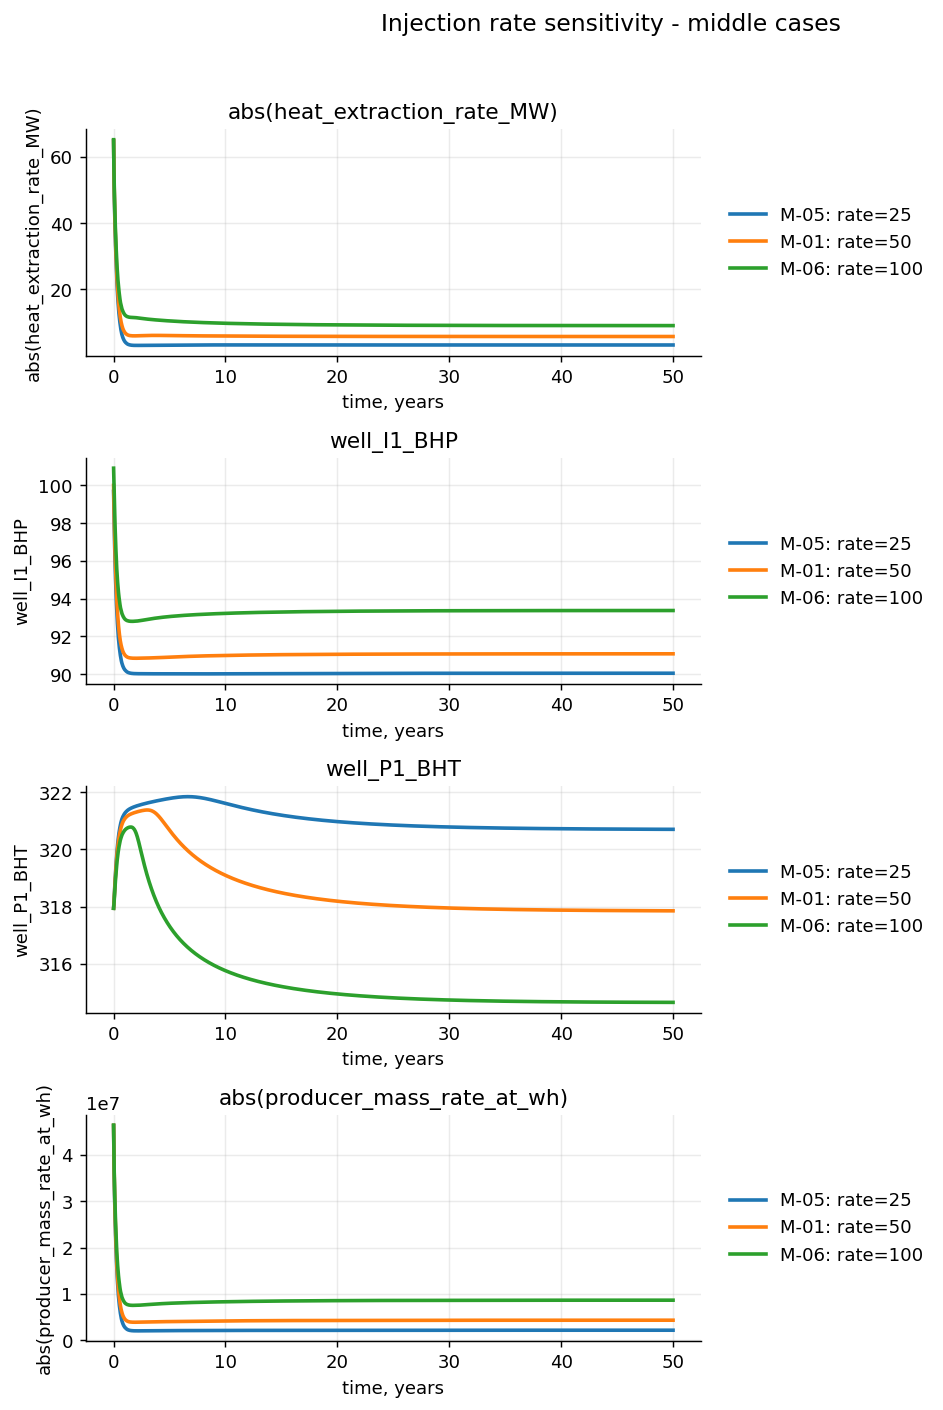

Using LCO2 mass-rate column for D-05 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-05\well_time_data.xlsx
Using LCO2 mass-rate column for D-01 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-01\well_time_data.xlsx
Using LCO2 mass-rate column for D-06 because CO2_rich is not present: E:\Pure_CO2_S\bhp control, 83c, 690well_dis\D-06\well_time_data.xlsx


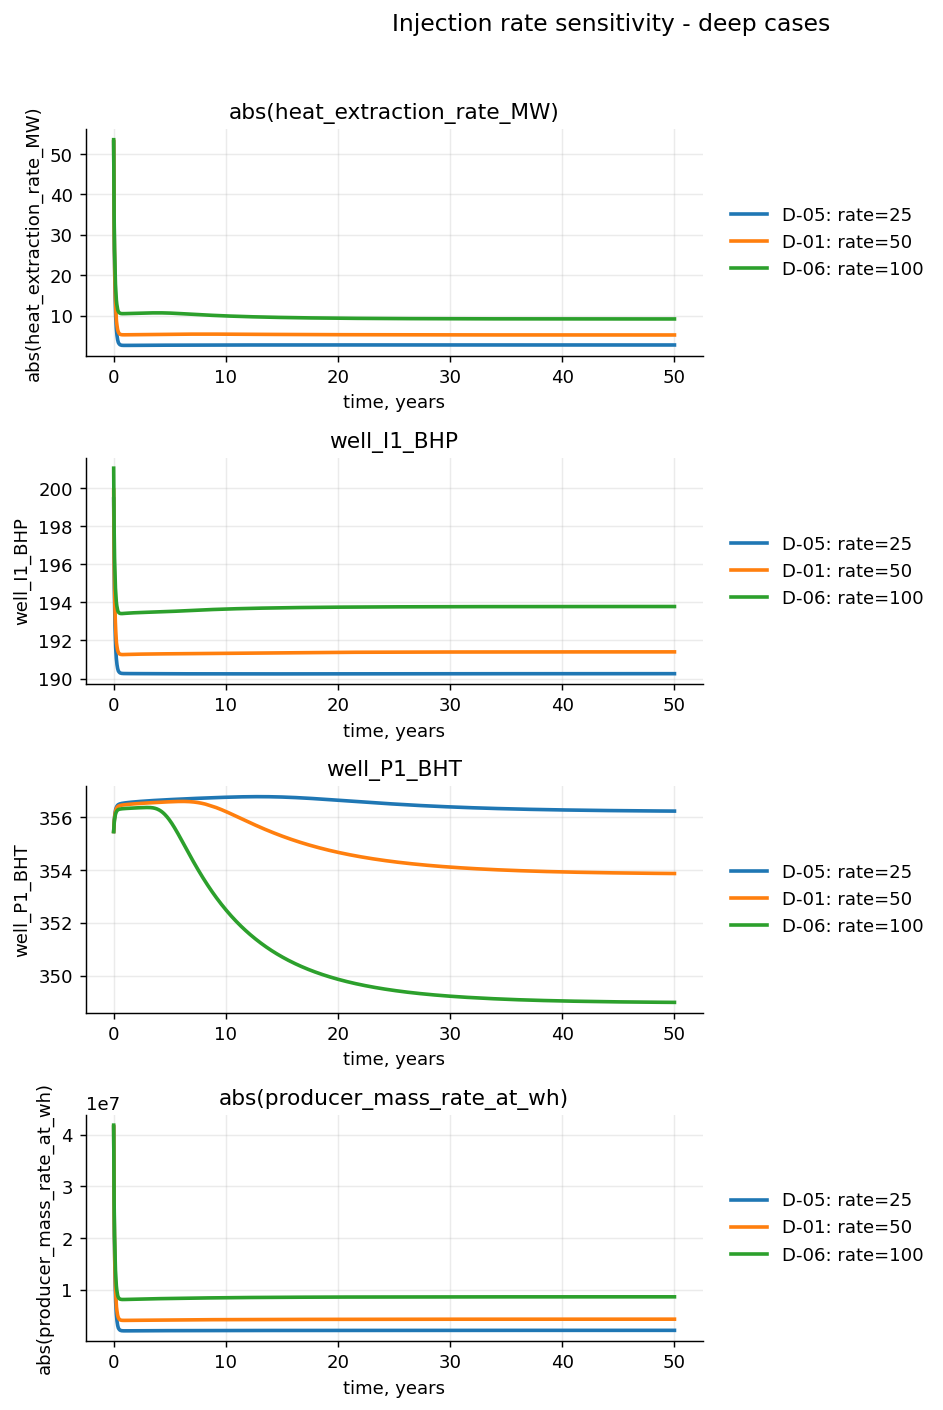

In [ ]:

# ===== Sensitivity analysis plots =====
SENSITIVITY_ROOT = Path(r"E:\Pure_CO2_S\bhp control, 83c, 690well_dis")
SENSITIVITY_SHALLOW_TEMPERATURE = "17C"  # "17C" or "16C"
SENSITIVITY_EXCEL_NAME = "well_time_data.xlsx"
SENSITIVITY_SKIP_INITIAL_TIME_STEPS = 20
SENSITIVITY_OUTPUT_DIR = SENSITIVITY_ROOT / "_sensitivity_figures"
SENSITIVITY_SAVE_FIGURES = False

SENSITIVITY_PRODUCER_MASS_RATE_COLUMN = "producer_mass_rate_at_wh"
SENSITIVITY_PRODUCER_H2O_MASS_RATE_COLUMN = "producer_H2O_mass_rate_at_wh"
SENSITIVITY_CO2_H2O_RATIO_COLUMN = CO2_H2O_RATIO_COLUMN

SENSITIVITY_VARIABLES = [
    HEAT_EXTRACTION_COLUMN,
    "well_I1_BHP",
    "well_P1_BHT",
    SENSITIVITY_PRODUCER_MASS_RATE_COLUMN,
    SENSITIVITY_CO2_H2O_RATIO_COLUMN,
]

SENSITIVITY_CASE_METADATA = [
    # Shallow, 500 m
    {"case": "S-01", "depth_model": "Shallow", "depth_m": 500, "purpose": "Baseline", "kh_md": 800, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "S-02", "depth_model": "Shallow", "depth_m": 500, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 78"},
    {"case": "S-03", "depth_model": "Shallow", "depth_m": 500, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 85"},
    {"case": "S-04", "depth_model": "Shallow", "depth_m": 500, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 66"},
    {"case": "S-05", "depth_model": "Shallow", "depth_m": 500, "purpose": "Injection rate: low", "kh_md": 800, "kvkh": 0.1, "injection_rate": 25, "heterogeneity": "Homogeneous"},
    {"case": "S-06", "depth_model": "Shallow", "depth_m": 500, "purpose": "Injection rate: high", "kh_md": 800, "kvkh": 0.1, "injection_rate": 100, "heterogeneity": "Homogeneous"},
    {"case": "S-07", "depth_model": "Shallow", "depth_m": 500, "purpose": "Vertical connectivity", "kh_md": 800, "kvkh": 1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    # Middle, 1000 m
    {"case": "M-01", "depth_model": "Middle", "depth_m": 1000, "purpose": "Baseline", "kh_md": 800, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "M-02", "depth_model": "Middle", "depth_m": 1000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 78"},
    {"case": "M-03", "depth_model": "Middle", "depth_m": 1000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 85"},
    {"case": "M-04", "depth_model": "Middle", "depth_m": 1000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 66"},
    {"case": "M-05", "depth_model": "Middle", "depth_m": 1000, "purpose": "Injection rate: low", "kh_md": 800, "kvkh": 0.1, "injection_rate": 25, "heterogeneity": "Homogeneous"},
    {"case": "M-06", "depth_model": "Middle", "depth_m": 1000, "purpose": "Injection rate: high", "kh_md": 800, "kvkh": 0.1, "injection_rate": 100, "heterogeneity": "Homogeneous"},
    {"case": "M-07", "depth_model": "Middle", "depth_m": 1000, "purpose": "Vertical connectivity", "kh_md": 800, "kvkh": 1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    # Deep, 2000 m
    {"case": "D-01", "depth_model": "Deep", "depth_m": 2000, "purpose": "Baseline", "kh_md": 800, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-02", "depth_model": "Deep", "depth_m": 2000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 78"},
    {"case": "D-03", "depth_model": "Deep", "depth_m": 2000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 85"},
    {"case": "D-04", "depth_model": "Deep", "depth_m": 2000, "purpose": "Heterogeneity", "kh_md": "realization-specific", "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Realization 66"},
    {"case": "D-05", "depth_model": "Deep", "depth_m": 2000, "purpose": "Injection rate: low", "kh_md": 800, "kvkh": 0.1, "injection_rate": 25, "heterogeneity": "Homogeneous"},
    {"case": "D-06", "depth_model": "Deep", "depth_m": 2000, "purpose": "Injection rate: high", "kh_md": 800, "kvkh": 0.1, "injection_rate": 100, "heterogeneity": "Homogeneous"},
    {"case": "D-07", "depth_model": "Deep", "depth_m": 2000, "purpose": "Horizontal permeability: low", "kh_md": 200, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-08", "depth_model": "Deep", "depth_m": 2000, "purpose": "Horizontal permeability: medium-low", "kh_md": 400, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-09", "depth_model": "Deep", "depth_m": 2000, "purpose": "Horizontal permeability: high", "kh_md": 1600, "kvkh": 0.1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-10", "depth_model": "Deep", "depth_m": 2000, "purpose": "Strong vertical anisotropy", "kh_md": 800, "kvkh": 0.01, "injection_rate": 50, "heterogeneity": "Homogeneous"},
    {"case": "D-11", "depth_model": "Deep", "depth_m": 2000, "purpose": "Isotropic permeability", "kh_md": 800, "kvkh": 1, "injection_rate": 50, "heterogeneity": "Homogeneous"},
]


def sensitivity_case_folder(case_id):
    if case_id.startswith("D-"):
        return SENSITIVITY_ROOT / case_id
    if case_id.startswith("M-"):
        if case_id in {"M-01", "M-05", "M-06", "M-07"}:
            return SENSITIVITY_ROOT / f"{case_id}-single_phase"
        return SENSITIVITY_ROOT / f"{case_id}_single_phase"
    if case_id.startswith("S-"):
        if SENSITIVITY_SHALLOW_TEMPERATURE.upper() == "17C":
            return SENSITIVITY_ROOT / "S_17C" / f"{case_id}_single_phase_17C"
        if case_id == "S-01":
            candidate = SENSITIVITY_ROOT / "S_16c" / "S-01_single_phase"
            return candidate if candidate.exists() else SENSITIVITY_ROOT / "S_16c" / "S-01_16c"
        return SENSITIVITY_ROOT / "S_16c" / f"{case_id}_single_phase"
    raise ValueError(f"Unsupported case ID: {case_id}")


def sensitivity_label(meta, label_mode="case"):
    case = meta["case"]
    if label_mode == "depth":
        return f"{case}: {meta['depth_m']} m"
    if label_mode == "kh":
        return f"{case}: kh={meta['kh_md']} mD"
    if label_mode == "kvkh":
        return f"{case}: kv/kh={meta['kvkh']}"
    if label_mode == "rate":
        return f"{case}: rate={meta['injection_rate']}"
    if label_mode == "heterogeneity":
        return f"{case}: {meta['heterogeneity']}"
    return f"{case}: {meta['purpose']}"


def sensitivity_excel_specs(case_ids, label_mode="case", require_existing=True):
    metadata = {meta["case"]: meta for meta in SENSITIVITY_CASE_METADATA}
    specs = []
    missing = []
    for case_id in case_ids:
        meta = metadata[case_id]
        case_dir = sensitivity_case_folder(case_id)
        path = case_dir / SENSITIVITY_EXCEL_NAME
        if not path.exists():
            missing.append(path)
            if require_existing:
                continue
        specs.append({
            "label": sensitivity_label(meta, label_mode),
            "path": path,
            "sheet_name": 0,
            **meta,
        })
    if missing:
        print("Missing sensitivity files:")
        for path in missing:
            print("  ", path)
    if not specs:
        raise FileNotFoundError("No sensitivity files found for selected case IDs")
    return specs


SENSITIVITY_PHASE_FALLBACKS = ("LCO2", "CO2_rich")


def sensitivity_phase_name(case_id):
    # Preferred rule for current depth-comparison outputs: shallow S cases use LCO2; middle/deep use CO2_rich.
    return "LCO2" if case_id.startswith("S-") else "CO2_rich"


def resolve_sensitivity_phase(df, case_id, path):
    preferred = sensitivity_phase_name(case_id)
    phases = [preferred] + [phase for phase in SENSITIVITY_PHASE_FALLBACKS if phase != preferred]
    for phase in phases:
        producer_mass_col = f"well_P1_mass_rate_{phase}_at_wh"
        if producer_mass_col in df.columns:
            if phase != preferred:
                print(f"Using {phase} mass-rate column for {case_id} because {preferred} is not present: {path}")
            return phase
    available_mass_cols = [col for col in df.columns if "mass_rate" in col]
    raise KeyError(
        f"No supported producer mass-rate column found in {Path(path).name} for {case_id}. "
        f"Tried phases: {phases}. Available mass-rate columns: {available_mass_cols}"
    )


def add_sensitivity_standard_columns(df, path, phase_name):
    df = df.copy()
    producer_mass_col = f"well_P1_mass_rate_{phase_name}_at_wh"
    injector_mass_col = f"well_I1_mass_rate_{phase_name}_at_wh"
    required = [
        producer_mass_col,
        PRODUCER_PRESSURE_COLUMN,
        PRODUCER_TEMPERATURE_COLUMN,
        INJECTOR_PRESSURE_COLUMN,
        INJECTOR_TEMPERATURE_COLUMN,
    ]
    try:
        require_columns(df, required, path)
    except KeyError as exc:
        available_mass_cols = [col for col in df.columns if "mass_rate" in col]
        raise KeyError(f"{exc}. Available mass-rate columns: {available_mass_cols}") from exc
    df[SENSITIVITY_PRODUCER_MASS_RATE_COLUMN] = pd.to_numeric(df[producer_mass_col], errors="coerce")
    if injector_mass_col in df.columns:
        df["injector_mass_rate_at_wh"] = pd.to_numeric(df[injector_mass_col], errors="coerce")
    h2o_mass_col = first_existing_column(df, [
        "well_P1_mass_rate_H2O_at_wh",
        "well_P1_mass_rate_aqueous_at_wh",
    ])
    if h2o_mass_col is not None:
        df[SENSITIVITY_PRODUCER_H2O_MASS_RATE_COLUMN] = pd.to_numeric(df[h2o_mass_col], errors="coerce")
    df = add_co2_h2o_mass_rate_ratio(df, path, out_col=SENSITIVITY_CO2_H2O_RATIO_COLUMN)
    producer_mass_rate_kg_per_day = np.abs(pd.to_numeric(df[producer_mass_col], errors="coerce"))
    h_produced = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df[PRODUCER_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df[PRODUCER_TEMPERATURE_COLUMN], errors="coerce"),
    )
    h_injected = co2_enthalpy_kj_per_kg(
        pd.to_numeric(df[INJECTOR_PRESSURE_COLUMN], errors="coerce"),
        pd.to_numeric(df[INJECTOR_TEMPERATURE_COLUMN], errors="coerce"),
    )
    df[HEAT_EXTRACTION_COLUMN] = producer_mass_rate_kg_per_day * (h_produced - h_injected) / 86400.0 / 1000.0
    df[f"{HEAT_EXTRACTION_COLUMN}_h_produced_kJ_per_kg"] = h_produced
    df[f"{HEAT_EXTRACTION_COLUMN}_h_injected_kJ_per_kg"] = h_injected
    df["sensitivity_phase_name"] = phase_name
    df["sensitivity_source_mass_rate_column"] = producer_mass_col
    df["sensitivity_source_h2o_mass_rate_column"] = h2o_mass_col
    return df


def load_sensitivity_cases(case_ids, label_mode="case"):
    specs = sensitivity_excel_specs(case_ids, label_mode=label_mode)
    cases = {}
    for spec in specs:
        label = spec["label"]
        path = Path(spec["path"])
        df = clean_columns(read_table(path, spec.get("sheet_name", 0)))
        tcol = find_time_column(df, TIME_COLUMN)
        df[tcol] = pd.to_numeric(df[tcol], errors="coerce")
        df = df.dropna(subset=[tcol]).sort_values(tcol).drop_duplicates(subset=[tcol], keep="last")
        skip_count = steps_to_skip(SENSITIVITY_SKIP_INITIAL_TIME_STEPS, label)
        if skip_count:
            df = df.iloc[skip_count:]
        if df.empty:
            raise ValueError(f"No rows left for {label!r} after skipping {skip_count} initial time steps")
        phase_name = resolve_sensitivity_phase(df, spec["case"], path)
        df = add_sensitivity_standard_columns(df, path, phase_name)
        cases[label] = {"df": df, "time_col": tcol, "path": path, "phase_name": phase_name, "metadata": spec}
    return cases


def safe_filename(text):
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in str(text)).strip("_")


def plot_sensitivity_group(group_name, case_ids, variables=SENSITIVITY_VARIABLES, label_mode="case"):
    group_cases = load_sensitivity_cases(case_ids, label_mode=label_mode)
    n = len(variables)
    fig, axes = plt.subplots(n, 1, figsize=(9.5, max(3.0, 2.7 * n)), squeeze=False)
    for ax, variable in zip(axes.ravel(), variables):
        for label, case in group_cases.items():
            x, y = get_series(case, variable)
            xs, ys = smooth_xy(x / TIME_SCALE, y)
            ax.plot(xs, ys, linewidth=2.0, label=label)
        ax.set_title(display_variable_name(variable))
        ax.set_xlabel(TIME_LABEL)
        ax.set_ylabel(display_variable_name(variable))
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
    fig.suptitle(group_name, y=1.0, fontsize=13)
    fig.tight_layout(rect=(0, 0, 0.78, 0.98))
    return fig, group_cases


SENSITIVITY_GROUPS = {
    # Cross-depth comparisons. Each group keeps geology/control settings matched and changes depth only.
    "Depth comparison - baseline cases": (["S-01", "M-01", "D-01"], "depth"),
    "Depth comparison - low injection rate": (["S-05", "M-05", "D-05"], "depth"),
    "Depth comparison - high injection rate": (["S-06", "M-06", "D-06"], "depth"),
    "Depth comparison - heterogeneity R78": (["S-02", "M-02", "D-02"], "depth"),
    "Depth comparison - heterogeneity R85": (["S-03", "M-03", "D-03"], "depth"),
    "Depth comparison - heterogeneity R66": (["S-04", "M-04", "D-04"], "depth"),
    "Depth comparison - isotropic kvkh": (["S-07", "M-07", "D-11"], "depth"),
    # Original within-depth sensitivity comparisons.
    "Horizontal permeability sensitivity - deep cases": (["D-07", "D-08", "D-01", "D-09"], "kh"),
    "kvkh sensitivity - shallow cases": (["S-01", "S-07"], "kvkh"),
    "kvkh sensitivity - middle cases": (["M-01", "M-07"], "kvkh"),
    "kvkh sensitivity - deep cases": (["D-10", "D-01", "D-11"], "kvkh"),
    "Injection rate sensitivity - shallow cases": (["S-05", "S-01", "S-06"], "rate"),
    "Injection rate sensitivity - middle cases": (["M-05", "M-01", "M-06"], "rate"),
    "Injection rate sensitivity - deep cases": (["D-05", "D-01", "D-06"], "rate"),
}

sensitivity_figures = {}
sensitivity_loaded_cases = {}
for group_name, (case_ids, label_mode) in SENSITIVITY_GROUPS.items():
    fig, group_cases = plot_sensitivity_group(group_name, case_ids, label_mode=label_mode)
    sensitivity_figures[group_name] = fig
    sensitivity_loaded_cases[group_name] = group_cases
    plt.show()
